In [1]:
import os 
os.chdir("..")

In [ ]:
import pandas as pd
import numpy as np
from datetime import timedelta
import xgboost as xgb
import matplotlib.pyplot as plt
from src.feature_engineering import apply_catboost_encoding, apply_robust_scaler, apply_target_encoding, apply_label_encoding_nn
from src.evaluation import evaluate_model
import shap
from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_val_score

/home/clfournier/home_dev/aaaaaaaaaaaaaaaaaaaaaa/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
train = pd.read_parquet('data/train_sales_data.parquet')
test = pd.read_parquet('data/test_sales_data.parquet')

# Configuration des splits temporels

In [4]:

train_min = train['date'].min()
train_max = train['date'].max()

split1_train_end = train_min + pd.DateOffset(years=2)
split1_test_start = split1_train_end + timedelta(days=1)
split1_test_end = split1_test_start + timedelta(weeks=8)

split2_train_end = train_min + pd.DateOffset(years=3)
split2_test_start = split2_train_end + timedelta(days=1)
split2_test_end = split2_test_start + timedelta(weeks=8)

split3_train_end = train_max

SPLITS = [
    {
        'name': 'Split 1 (2 ans)',
        'train_end': split1_train_end,
        'test_start': split1_test_start,
        'test_end': split1_test_end,
        'use_real_test': False
    },
    {
        'name': 'Split 2 (3 ans)',
        'train_end': split2_train_end,
        'test_start': split2_test_start,
        'test_end': split2_test_end,
        'use_real_test': False
    },
    {
        'name': 'Split 3 (Final)',
        'train_end': split3_train_end,
        'test_start': test['date'].min(),
        'test_end': test['date'].max(),
        'use_real_test': True
    }
]

In [5]:
print("Configuration des splits:")
print("-" * 80)
for split in SPLITS:
    print(f"{split['name']}:")
    print(f"  Train: {train_min} -> {split['train_end']}")
    print(f"  Test:  {split['test_start']} -> {split['test_end']}")

Configuration des splits:
--------------------------------------------------------------------------------
Split 1 (2 ans):
  Train: 2013-01-01 00:00:00 -> 2015-01-01 00:00:00
  Test:  2015-01-02 00:00:00 -> 2015-02-27 00:00:00
Split 2 (3 ans):
  Train: 2013-01-01 00:00:00 -> 2016-01-01 00:00:00
  Test:  2016-01-02 00:00:00 -> 2016-02-27 00:00:00
Split 3 (Final):
  Train: 2013-01-01 00:00:00 -> 2017-06-20 00:00:00
  Test:  2017-06-21 00:00:00 -> 2017-08-15 00:00:00


In [6]:
train.columns 

Index(['id', 'date', 'store_nbr', 'family', 'sales', 'onpromotion', 'city',
       'state', 'store_type', 'cluster', 'oil_price', 'oil_price_lag_8w',
       'oil_price_lag_8w_trend_30', 'holiday_type', 'is_holiday_local',
       'is_holiday_regional', 'is_holiday_national', 'day_of_week', 'month',
       'year', 'is_weekend', 'is_payday', 'month_sin', 'month_cos', 'day_sin',
       'day_cos', 'is_earthquake_impact', 'days_to_christmas', 'sales_lag_1',
       'sales_lag_2', 'sales_lag_3', 'sales_lag_7', 'sales_lag_14',
       'sales_lag_28', 'sales_lag_56', 'sales_lag_364', 'rolling_mean_7',
       'rolling_mean_28', 'log_sales', 'rolling_std_7', 'is_store_closed',
       'is_family_unactive', 'is_store_closed_lag_1',
       'is_family_unactive_lag_1'],
      dtype='object')

# Méthode Boosting

# Entrainement / évaluation du XGB

# Méthodologie de Prévision de Ventes - XGBoost Récursif

## 1. Architecture de Validation

### Validation Temporelle Multi-Splits

Trois périodes de validation pour mesurer la robustesse temporelle :
```
Split 1: Train [2013-2015] → Test [8 semaines début 2015]
Split 2: Train [2013-2016] → Test [8 semaines début 2016]  
Split 3: Train [2013-2017] → Test [8 semaines mi-2017]
```

Objectifs :
- Détecter l'overfitting temporel
- Mesurer l'impact de la profondeur historique (2 vs 3 vs 4.5 ans)
- Valider la généralisation sur différentes périodes

## 2. Prédiction Récursive (DirRec)

### Principe

Prédiction jour par jour en utilisant les prédictions passées comme features pour les jours futurs.
```
Jour 1:  features = lags du train              → prédit ventes J1
Jour 2:  features = lags incluant prédiction J1 → prédit ventes J2
Jour 3:  features = lags incluant prédictions J1-J2 → prédit ventes J3
...
Jour 56: features = lags incluant prédictions J1-J55 → prédit ventes J56
```

### Justification : Éviter le Data Leakage

Approche naïve (incorrecte) :
```python
# Utilise sales_lag_1 du test pour prédire le test
# sales_lag_1 du jour J+1 = ventes réelles du jour J (inconnues en production)
X_test = test[['sales_lag_1', 'sales_lag_7', ...]]
y_pred = model.predict(X_test)
```

Approche récursive (correcte) :
```python
#sales_lag_1 du jour J+1 = prédiction du jour J (disponible)
for day in test_dates:
    X_day = features_avec_predictions_passees(day)
    y_pred_day = model.predict(X_day)
    mettre_a_jour_lags(y_pred_day)
```

### Mise à Jour des Lags

Pour chaque prédiction du jour J :
- sales_lag_1 du jour J+1 = prédiction J
- sales_lag_7 du jour J+7 = prédiction J
- sales_lag_14 du jour J+14 = prédiction J
- rolling_mean_7 du jour J+1 à J+7 = moyenne incluant prédiction J

## 3. Système de Poids

### Exclusion des Observations Non-Pertinentes

Certaines observations doivent être exclues des métriques :
- Magasins fermés (is_store_closed = 1)
- Familles de produits non vendues (is_family_unactive = 1)

Implémentation :
```python
weights = np.ones(len(y_true))
weights[(is_store_closed == 1) | (is_family_unactive == 1)] = 0

mae = np.sum(weights * np.abs(y_true - y_pred)) / np.sum(weights)
```

Les observations avec weight = 0 ne contribuent pas aux métriques de performance.

## 4. Clipping des Prédictions

### Contrainte de Non-Négativité

Les ventes ne peuvent pas être négatives. Le modèle peut parfois prédire des valeurs négatives, notamment :
- Lors d'extrapolation hors distribution
- Avec des lags très faibles
- Sur des périodes atypiques

Application du clipping :
```python
y_pred_day = model.predict(X_day)
y_pred_day = np.maximum(y_pred_day, 0)  
```

Impact :
- Élimine les prédictions physiquement impossibles
- Améliore légèrement le RMSLE
- Garantit des prédictions réalistes pour la production

## 5. Features Utilisées

27 features après scaling :

Temporelles :
- year, month_sin, month_cos, day_sin, day_cos
- days_to_christmas

Lags de ventes :
- sales_lag_1, sales_lag_2, sales_lag_3
- sales_lag_7, sales_lag_14, sales_lag_28, sales_lag_56, sales_lag_364

Rolling features :
- rolling_mean_7, rolling_mean_28, rolling_std_7

Encodings catégoriels (CatBoost) :
- catboost_enc_store_nbr
- catboost_enc_family
- catboost_enc_city
- catboost_enc_cluster

Variables externes :
- onpromotion
- oil_price, oil_price_lag_8w, oil_price_lag_8w_trend_30

Indicateurs binaires :
- is_store_closed_lag_1
- is_family_unactive_lag_1

## 6. Modèle XGBoost

### Hyperparamètres
```python
XGBRegressor(
    objective='reg:squarederror',
    max_depth=8,
    learning_rate=0.05,
    n_estimators=500,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    device='cuda'
)
```

Justification :
- max_depth=8 : Compromis entre complexité et généralisation
- learning_rate=0.05 : Apprentissage progressif pour éviter l'overfitting
- n_estimators=500 : Nombre d'arbres suffisant pour convergence
- subsample=0.8, colsample_bytree=0.8 : Régularisation via sous-échantillonnage

## 7. Métriques d'Évaluation

Trois métriques principales (toutes avec poids) :

MAE (Mean Absolute Error) :
```
MAE = sum(weights * |y_true - y_pred|) / sum(weights)
```

RMSE (Root Mean Squared Error) :
```
RMSE = sqrt(sum(weights * (y_true - y_pred)²) / sum(weights))
```

RMSLE (Root Mean Squared Logarithmic Error) :
```
RMSLE = sqrt(sum(weights * (log(y_true + 1) - log(y_pred + 1))²) / sum(weights))
```

RMSLE pénalise moins les erreurs sur les grandes valeurs et est plus adapté aux ventes.

In [26]:
def train_and_evaluate_split_recursive_optimized(train_df, test_df, split_config, use_gpu=False):
    """
    Prédiction récursive OPTIMISÉE avec encodings calculés UNE SEULE FOIS.
    Les prédictions sont clippées à 0 (pas de valeurs négatives).
    
    Parameters
    ----------
    train_df : pd.DataFrame
        Dataframe d'entrainement complet
    test_df : pd.DataFrame
        Dataframe de test final
    split_config : dict
        Configuration du split (dates, nom, etc.)
    use_gpu : bool
        Utiliser le GPU pour XGBoost
    
    Returns
    -------
    dict
        Dictionnaire contenant les resultats, metriques et predictions
    """
    
    import warnings
    warnings.filterwarnings('ignore')
    
    # Creation des ensembles train et test pour ce split
    if split_config['use_real_test']:
        train_split = train_df.copy()
        test_split = test_df.copy()
    else:
        train_split = train_df[train_df['date'] <= split_config['train_end']].copy()
        test_split = train_df[
            (train_df['date'] >= split_config['test_start']) & 
            (train_df['date'] <= split_config['test_end'])
        ].copy()
    
    if len(test_split) == 0:
        return None
    
    print(f"Train: {train_split['date'].min()} -> {train_split['date'].max()}")
    print(f"Test:  {test_split['date'].min()} -> {test_split['date'].max()}")
    print(f"GPU:   {'Activé ✓' if use_gpu else 'Désactivé'}")
    
    # ========================================================================
    # PHASE 1: PREPARATION INITIALE (UNE SEULE FOIS)
    # ========================================================================
    
    print("\n[1/4] Feature engineering sur train...")
    train_processed = apply_catboost_encoding(
        train_split,
        cols=['store_nbr', 'family', 'city', 'cluster'],
        target='sales',
        nb_previous_days_to_ignore=56,
        fill_first_na=True
    )
    
    train_scaled, scaler = apply_robust_scaler(
        train_processed,
        exclude_cols=['id', 'date', 'store_nbr', 'family', 'city', 'state', 
                      'store_type', 'cluster', 'sales', 'log_sales',
                      'is_holiday_local', 'is_holiday_regional', 
                      'is_holiday_national', 'is_store_closed', 
                      'is_weekend', 'is_payday', 'is_earthquake_impact',
                      'is_family_unactive', 'holiday_type'],
        drop_original=True
    )
    
    # Definition des features
    exclude_from_features = [
        'id', 'date', 'sales', 'log_sales',
        'store_nbr', 'family', 'city', 'state', 'store_type', 'cluster', 'holiday_type'
    ]

    features = []
    for col in train_scaled.columns:
        if col in exclude_from_features:
            continue
        if train_scaled[col].dtype in ['int16', 'int32', 'int64', 'float16', 'float32', 'float64', 'bool']:
            features.append(col)
    
    X_train = train_scaled[features]
    y_train = train_scaled['sales']
    
    print(f"Nombre de features: {len(features)}")
    
    # ========================================================================
    # PHASE 2: ENTRAINEMENT DU MODELE
    # ========================================================================
    
    print(f"\n[2/4] Entrainement XGBoost {'sur GPU' if use_gpu else 'sur CPU'}...")
    
    if use_gpu:
        # XGBoost 3.x : utiliser device='cuda' au lieu de gpu_id
        model = xgb.XGBRegressor(
            objective='reg:squarederror',
            max_depth=8,
            learning_rate=0.05,
            n_estimators=500,
            subsample=0.8,
            colsample_bytree=0.8,
            min_child_weight=5,
            random_state=42,
            tree_method='hist',
            device='cuda',
            n_jobs=1
        )
    else:
        model = xgb.XGBRegressor(
            objective='reg:squarederror',
            max_depth=8,
            learning_rate=0.05,
            n_estimators=500,
            subsample=0.8,
            colsample_bytree=0.8,
            min_child_weight=5,
            random_state=42,
            tree_method='hist',
            device='cpu',
            n_jobs=-1
        )
    
    model.fit(X_train, y_train, verbose=False)
    print("✓ Entraînement terminé")
    
    # ========================================================================
    # PHASE 3: PREPARATION DES DONNEES POUR PREDICTION RECURSIVE
    # ========================================================================
    
    print("\n[3/4] Préparation des données test (encodings UNE SEULE FOIS)...")
    
    # Combiner train et test
    combined_data = pd.concat([train_split, test_split], ignore_index=True).copy()
    combined_data = combined_data.sort_values(['store_nbr', 'family', 'date']).reset_index(drop=True)
    
    # Appliquer CatBoost encoding UNE FOIS sur toutes les données
    combined_encoded = apply_catboost_encoding(
        combined_data,
        cols=['store_nbr', 'family', 'city', 'cluster'],
        target='sales',
        nb_previous_days_to_ignore=56,
        fill_first_na=True
    )
    
    # Appliquer le scaler
    combined_scaled = combined_encoded.copy()
    scaled_cols_in_train = [c for c in train_scaled.columns if c.startswith('scaled_')]
    original_cols_that_were_scaled = [c.replace('scaled_', '') for c in scaled_cols_in_train]
    cols_to_scale = [c for c in original_cols_that_were_scaled if c in combined_encoded.columns]
    
    if len(cols_to_scale) > 0:
        scaled_values = scaler.transform(combined_encoded[cols_to_scale])
        scaled_col_names = [f'scaled_{c}' for c in cols_to_scale]
        combined_scaled[scaled_col_names] = scaled_values
        combined_scaled.drop(columns=cols_to_scale, inplace=True)
    
    print("✓ Données préparées")
    
    # ========================================================================
    # PHASE 4: PREDICTION RECURSIVE JOUR PAR JOUR
    # ========================================================================
    
    test_dates = sorted(test_split['date'].unique())
    print(f"\n[4/4] Prédiction récursive sur {len(test_dates)} jours...")
    
    predictions_list = []
    n_clipped = 0  # Compteur de prédictions clippées
    
    for day_idx, current_date in enumerate(test_dates):
        # Extraire les données du jour (déjà encodées et scalées)
        day_mask = combined_scaled['date'] == current_date
        day_data = combined_scaled[day_mask].copy()
        
        if len(day_data) == 0:
            continue
        
        # Prédire pour ce jour
        X_day = day_data[features]
        y_pred_day = model.predict(X_day)
        
        # ====================================================================
        # NOUVEAU: CAPER LES PREDICTIONS A 0 (pas de valeurs négatives)
        # ====================================================================
        n_negative = (y_pred_day < 0).sum()
        n_clipped += n_negative
        y_pred_day = np.maximum(y_pred_day, 0)
        # ====================================================================
        
        # CRUCIAL: Mettre à jour les sales avec les prédictions (clippées)
        day_indices = combined_scaled[day_mask].index
        combined_scaled.loc[day_indices, 'sales'] = y_pred_day
        
        # Mettre à jour les lags pour les jours futurs
        for idx, (store, family) in enumerate(zip(day_data['store_nbr'], day_data['family'])):
            pred_value = y_pred_day[idx]  # Déjà clippé
            
            # Trouver les lignes futures pour ce store/family
            future_mask = (
                (combined_scaled['store_nbr'] == store) &
                (combined_scaled['family'] == family) &
                (combined_scaled['date'] > current_date)
            )
            
            if future_mask.sum() > 0:
                future_indices = combined_scaled[future_mask].index
                
                for future_idx in future_indices:
                    future_date = combined_scaled.loc[future_idx, 'date']
                    days_diff = (future_date - current_date).days
                    
                    # Mettre à jour les lags appropriés (simplifié)
                    lag_mapping = {
                        1: 'sales_lag_1',
                        2: 'sales_lag_2',
                        3: 'sales_lag_3',
                        7: 'sales_lag_7',
                        14: 'sales_lag_14',
                        28: 'sales_lag_28',
                        56: 'sales_lag_56'
                    }
                    
                    if days_diff in lag_mapping:
                        lag_col = lag_mapping[days_diff]
                        if lag_col in combined_scaled.columns:
                            combined_scaled.loc[future_idx, lag_col] = pred_value
                            
                            # Mettre à jour la version scalée si elle existe
                            scaled_lag_col = f'scaled_{lag_col}'
                            if scaled_lag_col in features:
                                # Trouver l'index de la colonne dans le scaler
                                col_idx = list(original_cols_that_were_scaled).index(lag_col) if lag_col in original_cols_that_were_scaled else None
                                if col_idx is not None:
                                    combined_scaled.loc[future_idx, scaled_lag_col] = scaled_values[future_idx, col_idx]
                    
                    # Mettre à jour rolling_mean_7 (si nécessaire)
                    if days_diff <= 7 and 'rolling_mean_7' in combined_scaled.columns:
                        past_7_mask = (
                            (combined_scaled['store_nbr'] == store) &
                            (combined_scaled['family'] == family) &
                            (combined_scaled['date'] >= future_date - pd.Timedelta(days=7)) &
                            (combined_scaled['date'] < future_date)
                        )
                        past_7_sales = combined_scaled.loc[past_7_mask, 'sales']
                        if len(past_7_sales) > 0:
                            new_rolling_mean = past_7_sales.mean()
                            combined_scaled.loc[future_idx, 'rolling_mean_7'] = new_rolling_mean
        
        # Stocker les prédictions (déjà clippées)
        day_results = pd.DataFrame({
            'date': day_data['date'].values,
            'store_nbr': day_data['store_nbr'].values,
            'family': day_data['family'].values,
            'y_pred': y_pred_day  # Déjà clippé à 0
        })
        
        predictions_list.append(day_results)
        
        if (day_idx + 1) % 7 == 0:
            print(f"  ✓ {day_idx + 1}/{len(test_dates)} jours traités")
    
    # Afficher le nombre de prédictions clippées
    if n_clipped > 0:
        print(f"\n {n_clipped} prédictions négatives clippées à 0")
    else:
        print(f"\n✓ Aucune prédiction négative")
    
    # Combiner toutes les prédictions
    all_predictions = pd.concat(predictions_list, ignore_index=True)
    
    # Récupérer les vraies valeurs
    test_split_sorted = test_split.sort_values(['date', 'store_nbr', 'family']).reset_index(drop=True)
    all_predictions = all_predictions.merge(
        test_split_sorted[['date', 'store_nbr', 'family', 'sales', 'is_store_closed', 'is_family_unactive']],
        on=['date', 'store_nbr', 'family'],
        how='left'
    )
    all_predictions = all_predictions.rename(columns={'sales': 'y_true'})
    
    # Evaluation
    print("\n[Evaluation] Calcul des métriques...")
    metrics = evaluate_model(
        y_true=all_predictions['y_true'].values,
        y_pred=all_predictions['y_pred'].values,
        is_store_closed=all_predictions['is_store_closed'].values,
        is_family_unactive=all_predictions['is_family_unactive'].values
    )
    
    results = {
        'split_name': split_config['name'] + ' (Recursive)',
        'train_size': len(train_split),
        'test_size': len(test_split),
        'train_start': train_split['date'].min(),
        'train_end': train_split['date'].max(),
        'test_start': test_split['date'].min(),
        'test_end': test_split['date'].max(),
        'metrics': metrics,
        'model': model,
        'features': features,
        'scaler': scaler,
        'predictions': all_predictions,
        'use_gpu': use_gpu,
        'n_clipped': n_clipped 
    }
    
    return results

In [27]:
# ============================================================================
# EXECUTION AVEC GPU
# ============================================================================

print("="*80)
print("PREDICTION RECURSIVE OPTIMISÉE - XGBOOST")
print("="*80)

# Test GPU
import xgboost as xgb
print(f"\nXGBoost version: {xgb.__version__}")

all_results_recursive = []

for split_config in SPLITS:
    print(f"\n{'='*80}")
    print(f"{split_config['name']}")
    print(f"{'='*80}")
    
    result = train_and_evaluate_split_recursive_optimized(
        train_df=train,
        test_df=test,
        split_config=split_config,
        use_gpu=True  # Active le GPU
    )
    
    if result is not None:
        all_results_recursive.append(result)
        print(f"\n✓ Résultats:")
        print(f"  RMSLE: {result['metrics']['rmsle']:.4f}")
        print(f"  MAE:   {result['metrics']['mae']:.4f}")
        print(f"  RMSE:  {result['metrics']['rmse']:.4f}")

# Comparaison des performances
print("\n" + "="*100)
print("COMPARAISON DES PERFORMANCES")
print("="*100)

comparison = []
for res in all_results_recursive:
    comparison.append({
        'Split': res['split_name'],
        'MAE': f"{res['metrics']['mae']:.4f}",
        'RMSE': f"{res['metrics']['rmse']:.4f}",
        'RMSLE': f"{res['metrics']['rmsle']:.4f}",
        'GPU': '✓' if res['use_gpu'] else '✗'
    })

comparison_df = pd.DataFrame(comparison)
print(comparison_df.to_string(index=False))

# Analyse de stabilite
rmsle_values = [res['metrics']['rmsle'] for res in all_results_recursive]
print(f"\nAnalyse de stabilite:")
print(f"  RMSLE moyen: {np.mean(rmsle_values):.4f}")
print(f"  Ecart-type:  {np.std(rmsle_values):.4f}")
print(f"  Min-Max:     [{min(rmsle_values):.4f}, {max(rmsle_values):.4f}]")

PREDICTION RECURSIVE OPTIMISÉE - XGBOOST

XGBoost version: 3.1.3

Split 1 (2 ans)
Train: 2013-01-01 00:00:00 -> 2015-01-01 00:00:00
Test:  2015-01-02 00:00:00 -> 2015-02-27 00:00:00
GPU:   Activé ✓

[1/4] Feature engineering sur train...
Variable 'store_nbr': 54 categories -> Dynamic alpha: 20.04
3024 NaN found in catboost_enc_store_nbr before filling.
Filled NaN in catboost_enc_store_nbr with global mean: 269.3495178222656
Variable 'family': 33 categories -> Dynamic alpha: 17.63
1848 NaN found in catboost_enc_family before filling.
Filled NaN in catboost_enc_family with global mean: 269.3495178222656
Variable 'city': 22 categories -> Dynamic alpha: 15.68
1232 NaN found in catboost_enc_city before filling.
Filled NaN in catboost_enc_city with global mean: 269.3495178222656
Variable 'cluster': 17 categories -> Dynamic alpha: 14.45
952 NaN found in catboost_enc_cluster before filling.
Filled NaN in catboost_enc_cluster with global mean: 269.3495178222656
27 colonnes créées avec préfixe '

# Visualisation des résultats 

In [ ]:
# Récupérer les résultats du Split 3 (dernier split) - VERSION RECURSIVE
split3_result = all_results_recursive[2]  # Index 2 = Split 3
predictions_df = split3_result['predictions']

# Vue d'ensemble des prédictions
print("="*80)
print("ANALYSE DES PREDICTIONS RECURSIVES - SPLIT 3 (TEST FINAL)")
print("="*80)
print(f"Nombre de prédictions: {len(predictions_df):,}")
print(f"RMSLE: {split3_result['metrics']['rmsle']:.4f}")
print(f"MAE: {split3_result['metrics']['mae']:.4f}")
print(f"RMSE: {split3_result['metrics']['rmse']:.4f}")
print(f"GPU: {'Activé ✓' if split3_result['use_gpu'] else 'Désactivé'}")

# Statistiques descriptives
print("\nStatistiques des valeurs réelles:")
print(f"  Min: {predictions_df['y_true'].min():.2f}")
print(f"  Max: {predictions_df['y_true'].max():.2f}")
print(f"  Moyenne: {predictions_df['y_true'].mean():.2f}")
print(f"  Médiane: {predictions_df['y_true'].median():.2f}")

print("\nStatistiques des prédictions:")
print(f"  Min: {predictions_df['y_pred'].min():.2f}")
print(f"  Max: {predictions_df['y_pred'].max():.2f}")
print(f"  Moyenne: {predictions_df['y_pred'].mean():.2f}")
print(f"  Médiane: {predictions_df['y_pred'].median():.2f}")

ANALYSE DES PREDICTIONS RECURSIVES - SPLIT 3 (TEST FINAL)
Nombre de prédictions: 99,792
RMSLE: 0.4463
MAE: 61.6660
RMSE: 220.9197
GPU: Activé ✓

Statistiques des valeurs réelles:
  Min: 0.00
  Max: 21180.00
  Moyenne: 473.39
  Médiane: 29.00

Statistiques des prédictions:
  Min: 0.00
  Max: 16329.82
  Moyenne: 475.00
  Médiane: 30.77


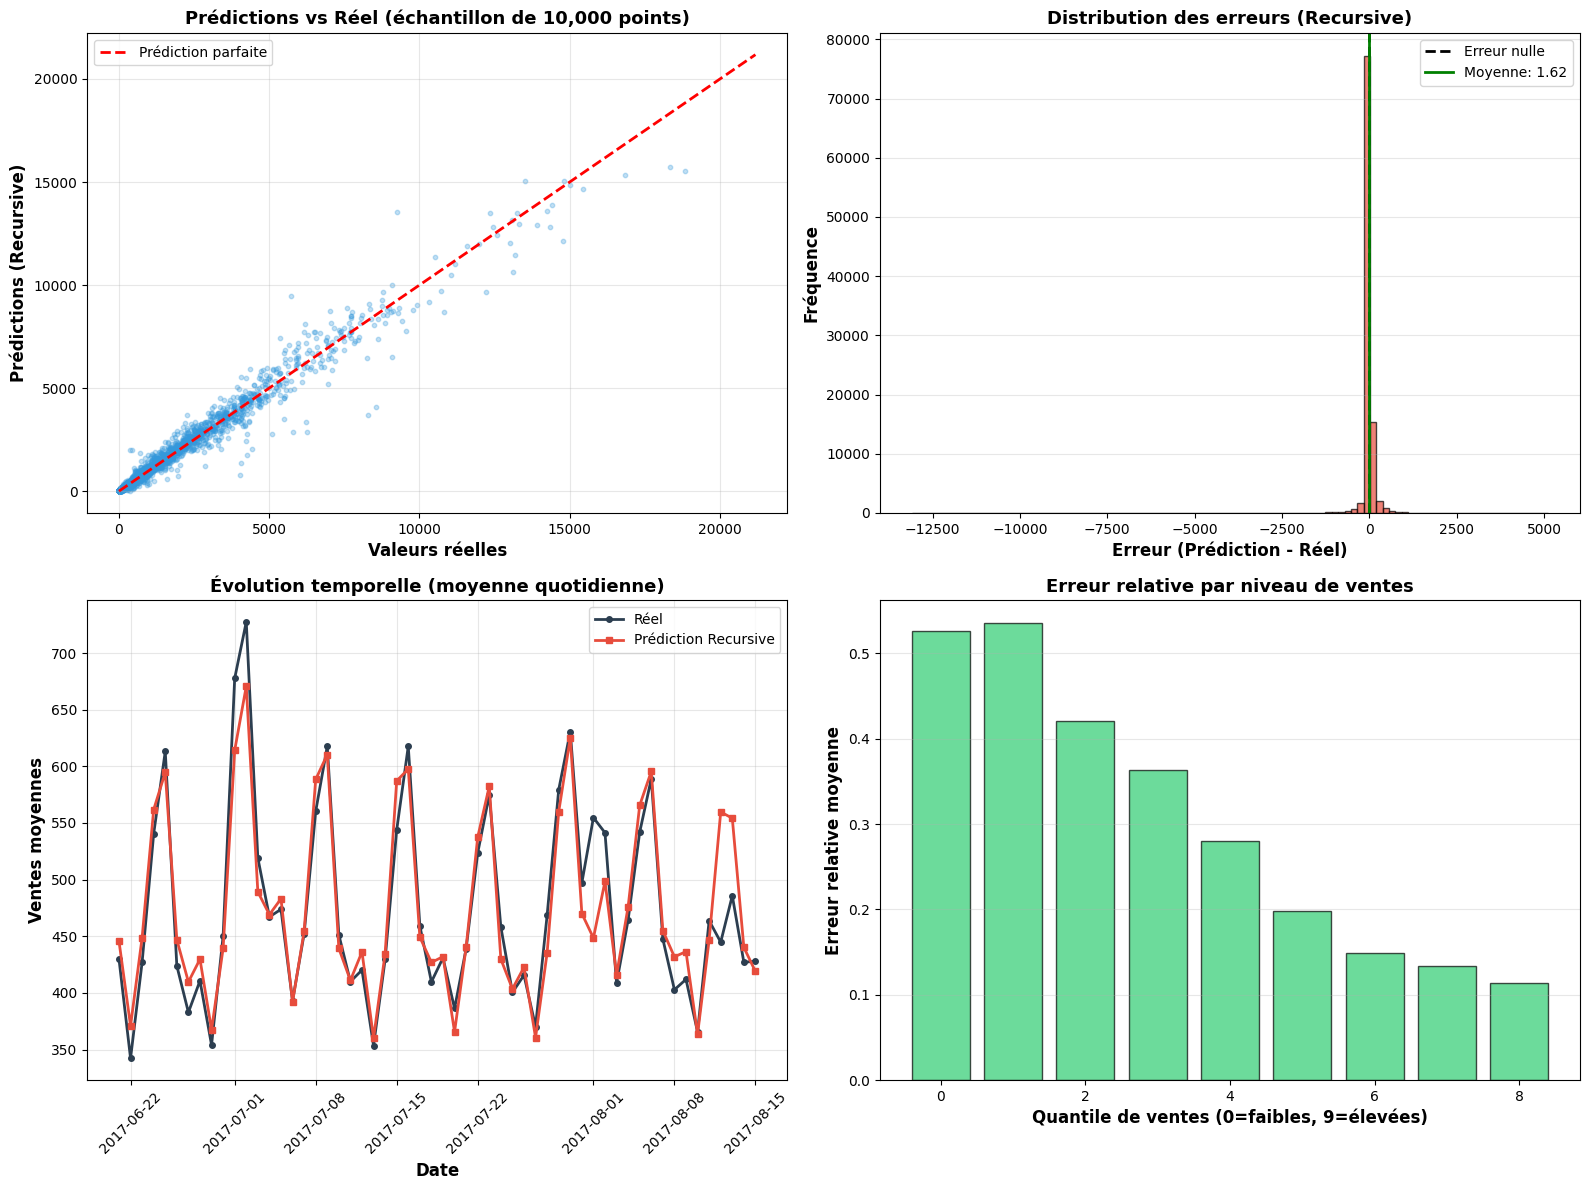

In [29]:

# ============================================================================
# GRAPHIQUES PRINCIPAUX
# ============================================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Scatter plot : Prédictions vs Réel
ax1 = axes[0, 0]
sample_size = min(10000, len(predictions_df))
sample_idx = np.random.choice(len(predictions_df), sample_size, replace=False)
sample_df = predictions_df.iloc[sample_idx]

ax1.scatter(sample_df['y_true'], sample_df['y_pred'], alpha=0.3, s=10, color='#3498db')
max_val = max(predictions_df['y_true'].max(), predictions_df['y_pred'].max())
ax1.plot([0, max_val], [0, max_val], 'r--', linewidth=2, label='Prédiction parfaite')
ax1.set_xlabel('Valeurs réelles', fontsize=12, fontweight='bold')
ax1.set_ylabel('Prédictions (Recursive)', fontsize=12, fontweight='bold')
ax1.set_title(f'Prédictions vs Réel (échantillon de {sample_size:,} points)', fontsize=13, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Distribution des erreurs
ax2 = axes[0, 1]
errors = predictions_df['y_pred'] - predictions_df['y_true']
ax2.hist(errors, bins=100, color='#e74c3c', alpha=0.7, edgecolor='black')
ax2.axvline(x=0, color='black', linestyle='--', linewidth=2, label='Erreur nulle')
ax2.axvline(x=errors.mean(), color='green', linestyle='-', linewidth=2, label=f'Moyenne: {errors.mean():.2f}')
ax2.set_xlabel('Erreur (Prédiction - Réel)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Fréquence', fontsize=12, fontweight='bold')
ax2.set_title('Distribution des erreurs (Recursive)', fontsize=13, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

# 3. Évolution temporelle (moyenne quotidienne)
ax3 = axes[1, 0]
daily_agg = predictions_df.groupby('date').agg({
    'y_true': 'mean',
    'y_pred': 'mean'
}).reset_index()

ax3.plot(daily_agg['date'], daily_agg['y_true'], label='Réel', linewidth=2, color='#2c3e50', marker='o', markersize=4)
ax3.plot(daily_agg['date'], daily_agg['y_pred'], label='Prédiction Recursive', linewidth=2, color='#e74c3c', marker='s', markersize=4)
ax3.set_xlabel('Date', fontsize=12, fontweight='bold')
ax3.set_ylabel('Ventes moyennes', fontsize=12, fontweight='bold')
ax3.set_title('Évolution temporelle (moyenne quotidienne)', fontsize=13, fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3)
ax3.tick_params(axis='x', rotation=45)

# 4. Erreurs relatives par quantile de ventes
ax4 = axes[1, 1]
predictions_df_copy = predictions_df.copy()
predictions_df_copy['abs_error'] = np.abs(predictions_df_copy['y_pred'] - predictions_df_copy['y_true'])
predictions_df_copy['rel_error'] = predictions_df_copy['abs_error'] / (predictions_df_copy['y_true'] + 1)

# Créer des quantiles de ventes
predictions_df_copy['sales_quantile'] = pd.qcut(predictions_df_copy['y_true'], q=10, labels=False, duplicates='drop')
quantile_errors = predictions_df_copy.groupby('sales_quantile')['rel_error'].mean()

ax4.bar(quantile_errors.index, quantile_errors.values, color='#2ecc71', alpha=0.7, edgecolor='black')
ax4.set_xlabel('Quantile de ventes (0=faibles, 9=élevées)', fontsize=12, fontweight='bold')
ax4.set_ylabel('Erreur relative moyenne', fontsize=12, fontweight='bold')
ax4.set_title('Erreur relative par niveau de ventes', fontsize=13, fontweight='bold')
ax4.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

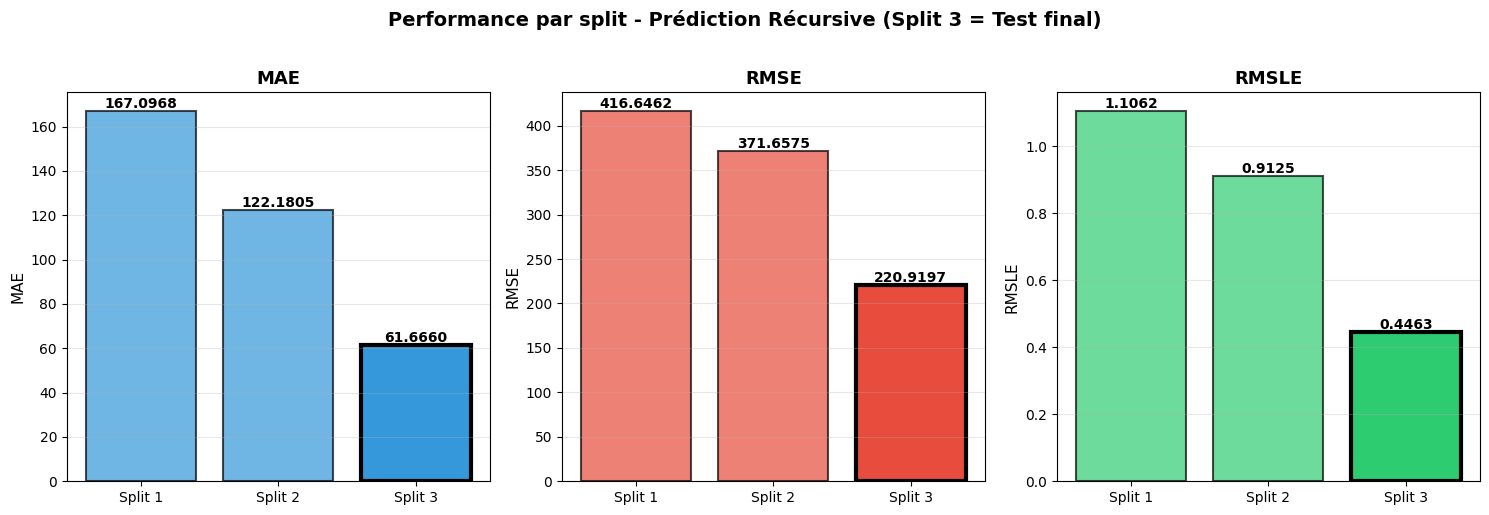


ANALYSE PAR STORE ET FAMILY

TOP 5 STORES (meilleures prédictions):
                 mae  nb_predictions
store_nbr                           
35         28.161066            1848
10         28.787603            1848
23         30.928932            1848
15         31.242931            1848
12         31.968081            1848

WORST 5 STORES (pires prédictions):
                  mae  nb_predictions
store_nbr                            
48          95.851974            1848
46          99.690842            1848
45         106.001190            1848
47         108.746239            1848
44         119.873482            1848

TOP 5 FAMILIES (meilleures prédictions):
                      mae  nb_predictions
family                                   
BOOKS            0.266413            3024
BABY CARE        0.385324            3024
HOME APPLIANCES  0.498954            3024
HARDWARE         1.185163            3024
MAGAZINES        2.530014            3024

WORST 5 FAMILIES (pires prédicti

In [30]:
# ============================================================================
# GRAPHIQUE COMPARAISON PAR SPLIT
# ============================================================================

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
metrics_names = ['mae', 'rmse', 'rmsle']
colors = ['#3498db', '#e74c3c', '#2ecc71']

for idx, metric in enumerate(metrics_names):
    values = [res['metrics'][metric] for res in all_results_recursive]
    labels = [f"Split {i+1}" for i in range(len(all_results_recursive))]
    
    bars = axes[idx].bar(range(len(values)), values, color=colors[idx], alpha=0.7, edgecolor='black', linewidth=1.5)
    
    # Mettre en évidence le Split 3 (test final)
    bars[-1].set_edgecolor('black')
    bars[-1].set_linewidth(3)
    bars[-1].set_alpha(1.0)
    
    axes[idx].set_xticks(range(len(values)))
    axes[idx].set_xticklabels(labels)
    axes[idx].set_title(f'{metric.upper()}', fontsize=13, fontweight='bold')
    axes[idx].set_ylabel(f'{metric.upper()}', fontsize=11)
    axes[idx].grid(axis='y', alpha=0.3)
    
    # Ajouter les valeurs sur les barres
    for i, v in enumerate(values):
        axes[idx].text(i, v, f'{v:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.suptitle('Performance par split - Prédiction Récursive (Split 3 = Test final)', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ============================================================================
# ANALYSE COMPLÉMENTAIRE
# ============================================================================

print("\n" + "="*80)
print("ANALYSE PAR STORE ET FAMILY")
print("="*80)

predictions_df_analysis = predictions_df.copy()
predictions_df_analysis['abs_error'] = np.abs(predictions_df_analysis['y_pred'] - predictions_df_analysis['y_true'])

# Top/Worst Stores
store_errors = predictions_df_analysis.groupby('store_nbr').agg({
    'abs_error': 'mean',
    'y_true': 'count'
}).rename(columns={'abs_error': 'mae', 'y_true': 'nb_predictions'}).sort_values('mae')

print("\nTOP 5 STORES (meilleures prédictions):")
print(store_errors.head(5).to_string())

print("\nWORST 5 STORES (pires prédictions):")
print(store_errors.tail(5).to_string())

# Top/Worst Families
family_errors = predictions_df_analysis.groupby('family').agg({
    'abs_error': 'mean',
    'y_true': 'count'
}).rename(columns={'abs_error': 'mae', 'y_true': 'nb_predictions'}).sort_values('mae')

print("\nTOP 5 FAMILIES (meilleures prédictions):")
print(family_errors.head(5).to_string())

print("\nWORST 5 FAMILIES (pires prédictions):")
print(family_errors.tail(5).to_string())

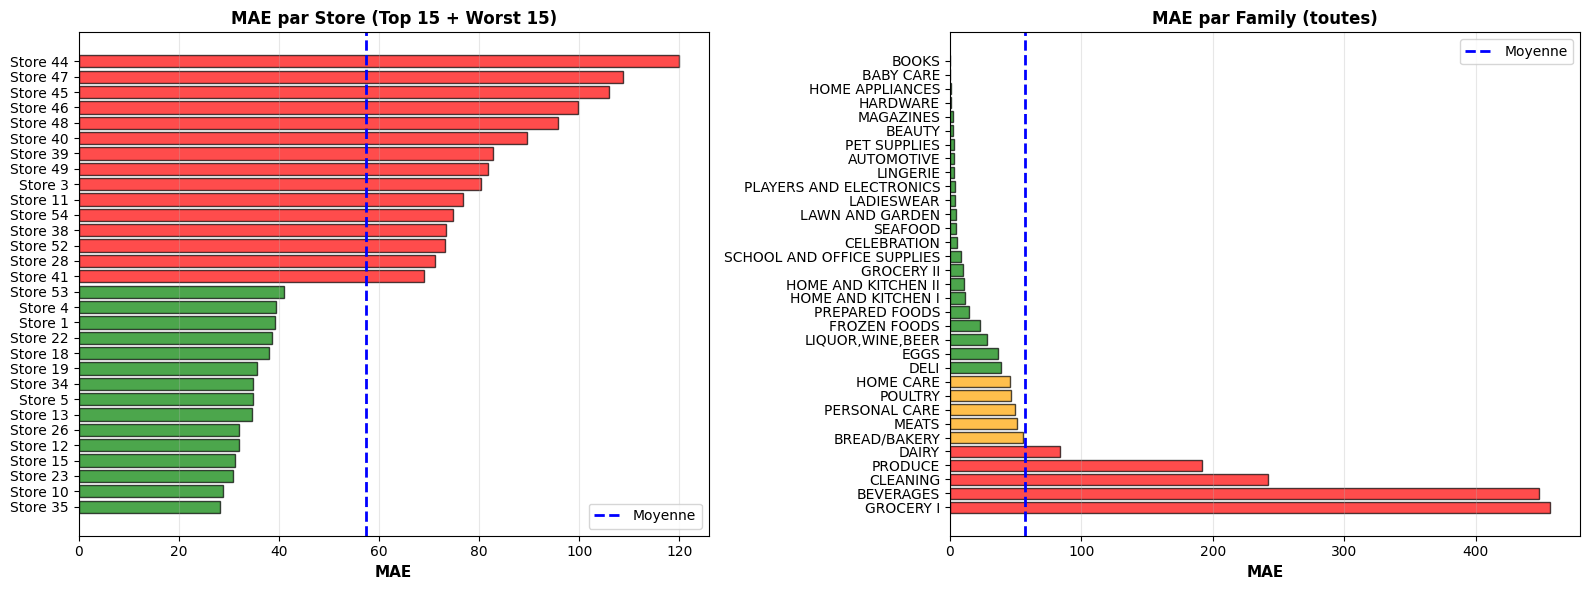

In [31]:
# ============================================================================
# VISUALISATION ERREURS PAR STORE ET FAMILY
# ============================================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Erreurs par Store (Top 15 et Worst 15)
ax1 = axes[0]
store_errors_sorted = store_errors.sort_values('mae')
top_stores = store_errors_sorted.head(15)
worst_stores = store_errors_sorted.tail(15)
stores_to_plot = pd.concat([top_stores, worst_stores])

colors_stores = ['green' if i < 15 else 'red' for i in range(len(stores_to_plot))]
ax1.barh(range(len(stores_to_plot)), stores_to_plot['mae'], color=colors_stores, alpha=0.7, edgecolor='black')
ax1.set_yticks(range(len(stores_to_plot)))
ax1.set_yticklabels([f"Store {s}" for s in stores_to_plot.index])
ax1.set_xlabel('MAE', fontsize=11, fontweight='bold')
ax1.set_title('MAE par Store (Top 15 + Worst 15)', fontsize=12, fontweight='bold')
ax1.grid(axis='x', alpha=0.3)
ax1.axvline(x=store_errors['mae'].mean(), color='blue', linestyle='--', linewidth=2, label='Moyenne')
ax1.legend()

# Erreurs par Family
ax2 = axes[1]
family_errors_sorted = family_errors.sort_values('mae', ascending=False)
colors_family = ['red' if i < 5 else 'orange' if i < 10 else 'green' for i in range(len(family_errors_sorted))]

ax2.barh(range(len(family_errors_sorted)), family_errors_sorted['mae'], color=colors_family, alpha=0.7, edgecolor='black')
ax2.set_yticks(range(len(family_errors_sorted)))
ax2.set_yticklabels(family_errors_sorted.index)
ax2.set_xlabel('MAE', fontsize=11, fontweight='bold')
ax2.set_title('MAE par Family (toutes)', fontsize=12, fontweight='bold')
ax2.grid(axis='x', alpha=0.3)
ax2.axvline(x=family_errors['mae'].mean(), color='blue', linestyle='--', linewidth=2, label='Moyenne')
ax2.legend()

plt.tight_layout()
plt.show()


Préparation des données pour SHAP...
Variable 'store_nbr': 54 categories -> Dynamic alpha: 20.04
3024 NaN found in catboost_enc_store_nbr before filling.
Filled NaN in catboost_enc_store_nbr with global mean: 353.7987976074219
Variable 'family': 33 categories -> Dynamic alpha: 17.63
1848 NaN found in catboost_enc_family before filling.
Filled NaN in catboost_enc_family with global mean: 353.7987976074219
Variable 'city': 22 categories -> Dynamic alpha: 15.68
1232 NaN found in catboost_enc_city before filling.
Filled NaN in catboost_enc_city with global mean: 353.7987976074219
Variable 'cluster': 17 categories -> Dynamic alpha: 14.45
952 NaN found in catboost_enc_cluster before filling.
Filled NaN in catboost_enc_cluster with global mean: 353.7987976074219
27 colonnes créées avec préfixe 'scaled_' : ['scaled_onpromotion', 'scaled_oil_price', 'scaled_oil_price_lag_8w', 'scaled_oil_price_lag_8w_trend_30', 'scaled_year', 'scaled_month_sin', 'scaled_month_cos', 'scaled_day_sin', 'scaled_day

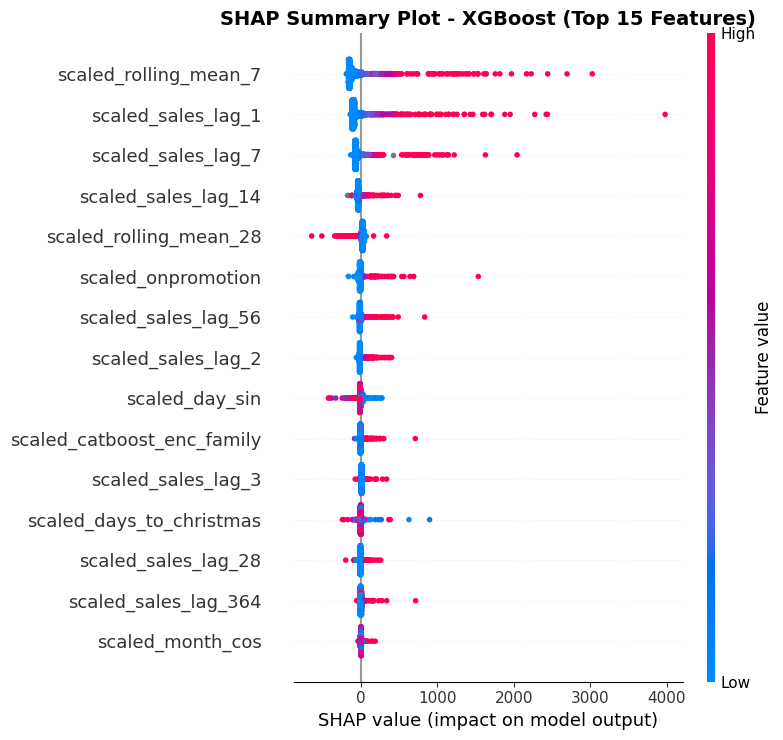

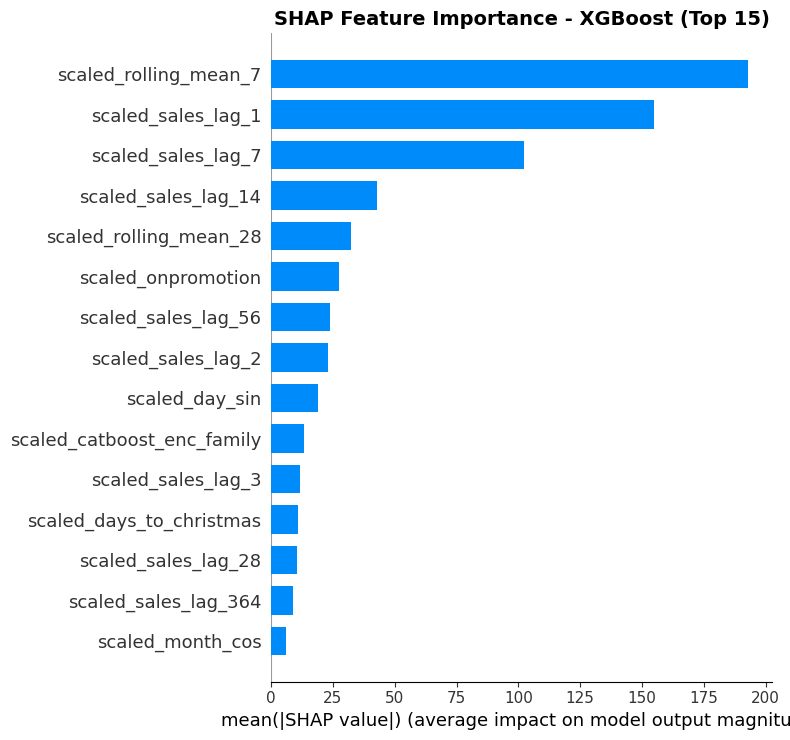

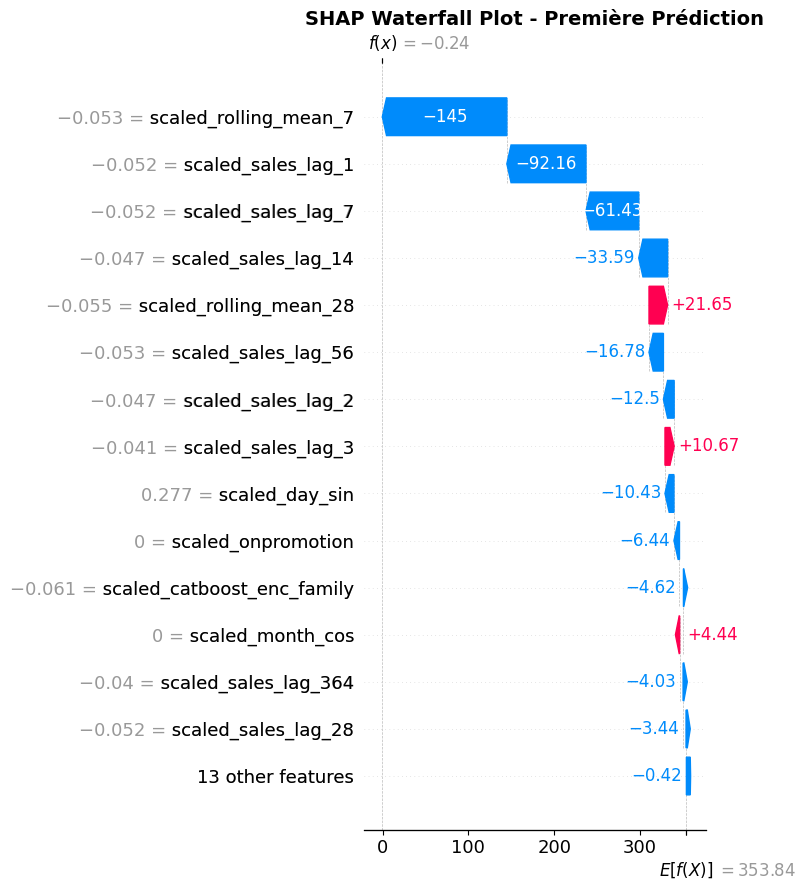


TOP 20 FEATURES PAR IMPORTANCE SHAP
                         feature  shap_importance
           scaled_rolling_mean_7       192.864456
              scaled_sales_lag_1       154.674759
              scaled_sales_lag_7       102.161797
             scaled_sales_lag_14        42.855824
          scaled_rolling_mean_28        32.306557
              scaled_onpromotion        27.311764
             scaled_sales_lag_56        24.009552
              scaled_sales_lag_2        22.993158
                  scaled_day_sin        18.978966
      scaled_catboost_enc_family        13.483059
              scaled_sales_lag_3        11.771289
        scaled_days_to_christmas        10.931966
             scaled_sales_lag_28        10.364154
            scaled_sales_lag_364         8.966283
                scaled_month_cos         5.870939
                scaled_month_sin         5.217945
                scaled_oil_price         5.211662
            scaled_rolling_std_7         3.910340
scaled_oil_pr

In [ ]:
# Récupérer le modèle et les données du Split 3
split3_result = all_results_recursive[2]
model = split3_result['model']
features = split3_result['features']

# Préparer un échantillon de données pour SHAP (trop lent sinon)
split3_predictions = split3_result['predictions']
sample_size = min(1000, len(split3_predictions))
sample_indices = np.random.choice(len(split3_predictions), sample_size, replace=False)

# Récupérer les features correspondantes (depuis combined_scaled)
# Il faut refaire le feature engineering pour avoir les bonnes valeurs
print("Préparation des données pour SHAP...")

# Simplification : utiliser directement les données du dernier split
train_split = train[train['date'] <= SPLITS[2]['train_end']].copy()
test_split = train[
    (train['date'] >= SPLITS[2]['test_start']) & 
    (train['date'] <= SPLITS[2]['test_end'])
].copy()

# Feature engineering
train_processed = apply_catboost_encoding(
    train_split,
    cols=['store_nbr', 'family', 'city', 'cluster'],
    target='sales',
    nb_previous_days_to_ignore=56,
    fill_first_na=True
)

train_scaled, scaler = apply_robust_scaler(
    train_processed,
    exclude_cols=['id', 'date', 'store_nbr', 'family', 'city', 'state', 
                  'store_type', 'cluster', 'sales', 'log_sales',
                  'is_holiday_local', 'is_holiday_regional', 
                  'is_holiday_national', 'is_store_closed', 
                  'is_weekend', 'is_payday', 'is_earthquake_impact',
                  'is_family_unactive', 'holiday_type'],
    drop_original=True
)

# Échantillon pour SHAP
X_sample = train_scaled[features].sample(n=sample_size, random_state=42)

print(f"Calcul des valeurs SHAP sur {sample_size} observations...")

# Créer l'explainer
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_sample)

print("✓ Valeurs SHAP calculées")

# ============================================================================
# VISUALISATIONS SHAP
# ============================================================================

# 1. Summary plot (beeswarm) - Top 15 features
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_sample, max_display=15, show=False)
plt.title('SHAP Summary Plot - XGBoost (Top 15 Features)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 2. Bar plot - Importance moyenne absolue
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_sample, plot_type='bar', max_display=15, show=False)
plt.title('SHAP Feature Importance - XGBoost (Top 15)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 3. Waterfall plot - Explication d'une prédiction
plt.figure(figsize=(10, 8))
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[0],
        base_values=explainer.expected_value,
        data=X_sample.iloc[0],
        feature_names=features
    ),
    max_display=15,
    show=False
)
plt.title('SHAP Waterfall Plot - Première Prédiction', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 5. Feature importance DataFrame
shap_importance_df = pd.DataFrame({
    'feature': features,
    'shap_importance': np.abs(shap_values).mean(axis=0)
}).sort_values('shap_importance', ascending=False)

print("\n" + "="*80)
print("TOP 20 FEATURES PAR IMPORTANCE SHAP")
print("="*80)
print(shap_importance_df.head(20).to_string(index=False))

# Méthode de Bagging (RF)

In [ ]:
from sklearn.ensemble import RandomForestRegressor
import warnings

def train_and_evaluate_split_rf_recursive(train_df, test_df, split_config, hyperparams=None):
    """
    Prédiction récursive Random Forest avec clipping à 0.
    
    Parameters
    ----------
    train_df : pd.DataFrame
        Dataframe d'entrainement complet
    test_df : pd.DataFrame
        Dataframe de test final
    split_config : dict
        Configuration du split (dates, nom, etc.)
    hyperparams : dict, optional
        Hyperparametres Random Forest personnalises
    
    Returns
    -------
    dict
        Dictionnaire contenant les resultats, metriques et predictions
    """
    
    warnings.filterwarnings('ignore')
    
    # Creation des ensembles train et test pour ce split
    if split_config['use_real_test']:
        train_split = train_df.copy()
        test_split = test_df.copy()
    else:
        train_split = train_df[train_df['date'] <= split_config['train_end']].copy()
        test_split = train_df[
            (train_df['date'] >= split_config['test_start']) & 
            (train_df['date'] <= split_config['test_end'])
        ].copy()
    
    if len(test_split) == 0:
        return None
    
    print(f"Train: {train_split['date'].min()} -> {train_split['date'].max()}")
    print(f"Test:  {test_split['date'].min()} -> {test_split['date'].max()}")
    
    # ========================================================================
    # PHASE 1: PREPARATION INITIALE
    # ========================================================================
    
    print("\n[1/4] Feature engineering sur train...")
    train_processed = apply_catboost_encoding(
        train_split,
        cols=['store_nbr', 'family', 'city', 'cluster'],
        target='sales',
        nb_previous_days_to_ignore=56,
        fill_first_na=True
    )
    
    train_scaled, scaler = apply_robust_scaler(
        train_processed,
        exclude_cols=['id', 'date', 'store_nbr', 'family', 'city', 'state', 
                      'store_type', 'cluster', 'sales', 'log_sales',
                      'is_holiday_local', 'is_holiday_regional', 
                      'is_holiday_national', 'is_store_closed', 
                      'is_weekend', 'is_payday', 'is_earthquake_impact',
                      'is_family_unactive', 'holiday_type'],
        drop_original=True
    )
    
    # Definition des features
    exclude_from_features = [
        'id', 'date', 'sales', 'log_sales',
        'store_nbr', 'family', 'city', 'state', 'store_type', 'cluster', 'holiday_type'
    ]

    features = []
    for col in train_scaled.columns:
        if col in exclude_from_features:
            continue
        if train_scaled[col].dtype in ['int16', 'int32', 'int64', 'float16', 'float32', 'float64', 'bool']:
            features.append(col)
    
    X_train = train_scaled[features]
    y_train = train_scaled['sales']
    
    print(f"Nombre de features: {len(features)}")
    
    # ========================================================================
    # PHASE 2: ENTRAINEMENT RANDOM FOREST
    # ========================================================================
    
    print(f"\n[2/4] Entrainement Random Forest...")
    
    # Hyperparametres par defaut ou personnalises
    if hyperparams is None:
        hyperparams = {
            'n_estimators': 200,
            'max_depth': 20,
            'min_samples_split': 10,
            'min_samples_leaf': 5,
            'max_features': 'sqrt',
            'bootstrap': True,
            'n_jobs': -1,
            'random_state': 42
        }
    
    model = RandomForestRegressor(**hyperparams)
    model.fit(X_train, y_train)
    print("✓ Entraînement terminé")
    
    # ========================================================================
    # PHASE 3: PREPARATION DES DONNEES TEST
    # ========================================================================
    
    print("\n[3/4] Préparation des données test (encodings UNE SEULE FOIS)...")
    
    # Combiner train et test
    combined_data = pd.concat([train_split, test_split], ignore_index=True).copy()
    combined_data = combined_data.sort_values(['store_nbr', 'family', 'date']).reset_index(drop=True)
    
    # Appliquer CatBoost encoding UNE FOIS
    combined_encoded = apply_catboost_encoding(
        combined_data,
        cols=['store_nbr', 'family', 'city', 'cluster'],
        target='sales',
        nb_previous_days_to_ignore=56,
        fill_first_na=True
    )
    
    # Appliquer le scaler
    combined_scaled = combined_encoded.copy()
    scaled_cols_in_train = [c for c in train_scaled.columns if c.startswith('scaled_')]
    original_cols_that_were_scaled = [c.replace('scaled_', '') for c in scaled_cols_in_train]
    cols_to_scale = [c for c in original_cols_that_were_scaled if c in combined_encoded.columns]
    
    if len(cols_to_scale) > 0:
        scaled_values = scaler.transform(combined_encoded[cols_to_scale])
        scaled_col_names = [f'scaled_{c}' for c in cols_to_scale]
        combined_scaled[scaled_col_names] = scaled_values
        combined_scaled.drop(columns=cols_to_scale, inplace=True)
    
    print("✓ Données préparées")
    
    # ========================================================================
    # PHASE 4: PREDICTION RECURSIVE
    # ========================================================================
    
    test_dates = sorted(test_split['date'].unique())
    print(f"\n[4/4] Prédiction récursive sur {len(test_dates)} jours...")
    
    predictions_list = []
    n_clipped = 0
    
    for day_idx, current_date in enumerate(test_dates):
        # Extraire les données du jour
        day_mask = combined_scaled['date'] == current_date
        day_data = combined_scaled[day_mask].copy()
        
        if len(day_data) == 0:
            continue
        
        # Prédire
        X_day = day_data[features]
        y_pred_day = model.predict(X_day)
        
        # CLIPPING A 0
        n_negative = (y_pred_day < 0).sum()
        n_clipped += n_negative
        y_pred_day = np.maximum(y_pred_day, 0)
        
        # Mettre à jour les sales
        day_indices = combined_scaled[day_mask].index
        combined_scaled.loc[day_indices, 'sales'] = y_pred_day
        
        # Mettre à jour les lags
        for idx, (store, family) in enumerate(zip(day_data['store_nbr'], day_data['family'])):
            pred_value = y_pred_day[idx]
            
            future_mask = (
                (combined_scaled['store_nbr'] == store) &
                (combined_scaled['family'] == family) &
                (combined_scaled['date'] > current_date)
            )
            
            if future_mask.sum() > 0:
                future_indices = combined_scaled[future_mask].index
                
                for future_idx in future_indices:
                    future_date = combined_scaled.loc[future_idx, 'date']
                    days_diff = (future_date - current_date).days
                    
                    lag_mapping = {
                        1: 'sales_lag_1',
                        2: 'sales_lag_2',
                        3: 'sales_lag_3',
                        7: 'sales_lag_7',
                        14: 'sales_lag_14',
                        28: 'sales_lag_28',
                        56: 'sales_lag_56'
                    }
                    
                    if days_diff in lag_mapping:
                        lag_col = lag_mapping[days_diff]
                        if lag_col in combined_scaled.columns:
                            combined_scaled.loc[future_idx, lag_col] = pred_value
                            
                            scaled_lag_col = f'scaled_{lag_col}'
                            if scaled_lag_col in features:
                                col_idx = list(original_cols_that_were_scaled).index(lag_col) if lag_col in original_cols_that_were_scaled else None
                                if col_idx is not None:
                                    combined_scaled.loc[future_idx, scaled_lag_col] = scaled_values[future_idx, col_idx]
                    
                    if days_diff <= 7 and 'rolling_mean_7' in combined_scaled.columns:
                        past_7_mask = (
                            (combined_scaled['store_nbr'] == store) &
                            (combined_scaled['family'] == family) &
                            (combined_scaled['date'] >= future_date - pd.Timedelta(days=7)) &
                            (combined_scaled['date'] < future_date)
                        )
                        past_7_sales = combined_scaled.loc[past_7_mask, 'sales']
                        if len(past_7_sales) > 0:
                            new_rolling_mean = past_7_sales.mean()
                            combined_scaled.loc[future_idx, 'rolling_mean_7'] = new_rolling_mean
        
        # Stocker les prédictions
        day_results = pd.DataFrame({
            'date': day_data['date'].values,
            'store_nbr': day_data['store_nbr'].values,
            'family': day_data['family'].values,
            'y_pred': y_pred_day
        })
        
        predictions_list.append(day_results)
        
        if (day_idx + 1) % 7 == 0:
            print(f"  ✓ {day_idx + 1}/{len(test_dates)} jours traités")
    
    # Afficher clipping
    if n_clipped > 0:
        print(f"\n  {n_clipped} prédictions négatives clippées à 0")
    else:
        print(f"\n✓ Aucune prédiction négative")
    
    # Combiner prédictions
    all_predictions = pd.concat(predictions_list, ignore_index=True)
    
    # Récupérer vraies valeurs
    test_split_sorted = test_split.sort_values(['date', 'store_nbr', 'family']).reset_index(drop=True)
    all_predictions = all_predictions.merge(
        test_split_sorted[['date', 'store_nbr', 'family', 'sales', 'is_store_closed', 'is_family_unactive']],
        on=['date', 'store_nbr', 'family'],
        how='left'
    )
    all_predictions = all_predictions.rename(columns={'sales': 'y_true'})
    
    # Evaluation
    print("\n[Evaluation] Calcul des métriques...")
    metrics = evaluate_model(
        y_true=all_predictions['y_true'].values,
        y_pred=all_predictions['y_pred'].values,
        is_store_closed=all_predictions['is_store_closed'].values,
        is_family_unactive=all_predictions['is_family_unactive'].values
    )
    
    results = {
        'split_name': split_config['name'] + ' (RF Recursive)',
        'train_size': len(train_split),
        'test_size': len(test_split),
        'train_start': train_split['date'].min(),
        'train_end': train_split['date'].max(),
        'test_start': test_split['date'].min(),
        'test_end': test_split['date'].max(),
        'metrics': metrics,
        'model': model,
        'features': features,
        'scaler': scaler,
        'predictions': all_predictions,
        'n_clipped': n_clipped
    }
    
    return results

In [36]:
# ============================================================================
# EXECUTION RANDOM FOREST RECURSIVE
# ============================================================================

print("="*80)
print("RANDOM FOREST - PREDICTION RECURSIVE")
print("="*80)

all_results_rf_recursive = []

for split_config in SPLITS:
    print(f"\n{'='*80}")
    print(f"{split_config['name']}")
    print(f"{'='*80}")
    
    result = train_and_evaluate_split_rf_recursive(
        train_df=train,
        test_df=test,
        split_config=split_config
    )
    
    if result is not None:
        all_results_rf_recursive.append(result)
        print(f"\n✓ Résultats:")
        print(f"  RMSLE: {result['metrics']['rmsle']:.4f}")
        print(f"  MAE:   {result['metrics']['mae']:.4f}")
        print(f"  RMSE:  {result['metrics']['rmse']:.4f}")

# Comparaison
print("\n" + "="*100)
print("COMPARAISON XGBoost vs Random Forest (Recursive)")
print("="*100)

comparison = []
for i in range(len(SPLITS)):
    comparison.append({
        'Split': SPLITS[i]['name'],
        'XGB_RMSLE': f"{all_results_recursive[i]['metrics']['rmsle']:.4f}",
        'RF_RMSLE': f"{all_results_rf_recursive[i]['metrics']['rmsle']:.4f}",
        'XGB_MAE': f"{all_results_recursive[i]['metrics']['mae']:.4f}",
        'RF_MAE': f"{all_results_rf_recursive[i]['metrics']['mae']:.4f}"
    })

comparison_df = pd.DataFrame(comparison)
print(comparison_df.to_string(index=False))

RANDOM FOREST - PREDICTION RECURSIVE

Split 1 (2 ans)
Train: 2013-01-01 00:00:00 -> 2015-01-01 00:00:00
Test:  2015-01-02 00:00:00 -> 2015-02-27 00:00:00

[1/4] Feature engineering sur train...
Variable 'store_nbr': 54 categories -> Dynamic alpha: 20.04
3024 NaN found in catboost_enc_store_nbr before filling.
Filled NaN in catboost_enc_store_nbr with global mean: 269.3495178222656
Variable 'family': 33 categories -> Dynamic alpha: 17.63
1848 NaN found in catboost_enc_family before filling.
Filled NaN in catboost_enc_family with global mean: 269.3495178222656
Variable 'city': 22 categories -> Dynamic alpha: 15.68
1232 NaN found in catboost_enc_city before filling.
Filled NaN in catboost_enc_city with global mean: 269.3495178222656
Variable 'cluster': 17 categories -> Dynamic alpha: 14.45
952 NaN found in catboost_enc_cluster before filling.
Filled NaN in catboost_enc_cluster with global mean: 269.3495178222656
27 colonnes créées avec préfixe 'scaled_' : ['scaled_onpromotion', 'scaled_oi

In [40]:
# Récupérer les résultats du Split 3 Random Forest
split3_result_rf = all_results_rf_recursive[2]  # Index 2 = Split 3
predictions_df_rf = split3_result_rf['predictions']

# Vue d'ensemble des prédictions
print("="*80)
print("ANALYSE DES PREDICTIONS RECURSIVES - RANDOM FOREST - SPLIT 3")
print("="*80)
print(f"Nombre de prédictions: {len(predictions_df_rf):,}")
print(f"RMSLE: {split3_result_rf['metrics']['rmsle']:.4f}")
print(f"MAE: {split3_result_rf['metrics']['mae']:.4f}")
print(f"RMSE: {split3_result_rf['metrics']['rmse']:.4f}")

# Statistiques descriptives
print("\nStatistiques des valeurs réelles:")
print(f"  Min: {predictions_df_rf['y_true'].min():.2f}")
print(f"  Max: {predictions_df_rf['y_true'].max():.2f}")
print(f"  Moyenne: {predictions_df_rf['y_true'].mean():.2f}")
print(f"  Médiane: {predictions_df_rf['y_true'].median():.2f}")

print("\nStatistiques des prédictions:")
print(f"  Min: {predictions_df_rf['y_pred'].min():.2f}")
print(f"  Max: {predictions_df_rf['y_pred'].max():.2f}")
print(f"  Moyenne: {predictions_df_rf['y_pred'].mean():.2f}")
print(f"  Médiane: {predictions_df_rf['y_pred'].median():.2f}")

ANALYSE DES PREDICTIONS RECURSIVES - RANDOM FOREST - SPLIT 3
Nombre de prédictions: 99,792
RMSLE: 0.4188
MAE: 61.8516
RMSE: 216.4034

Statistiques des valeurs réelles:
  Min: 0.00
  Max: 21180.00
  Moyenne: 473.39
  Médiane: 29.00

Statistiques des prédictions:
  Min: 0.11
  Max: 17112.81
  Moyenne: 481.26
  Médiane: 31.14


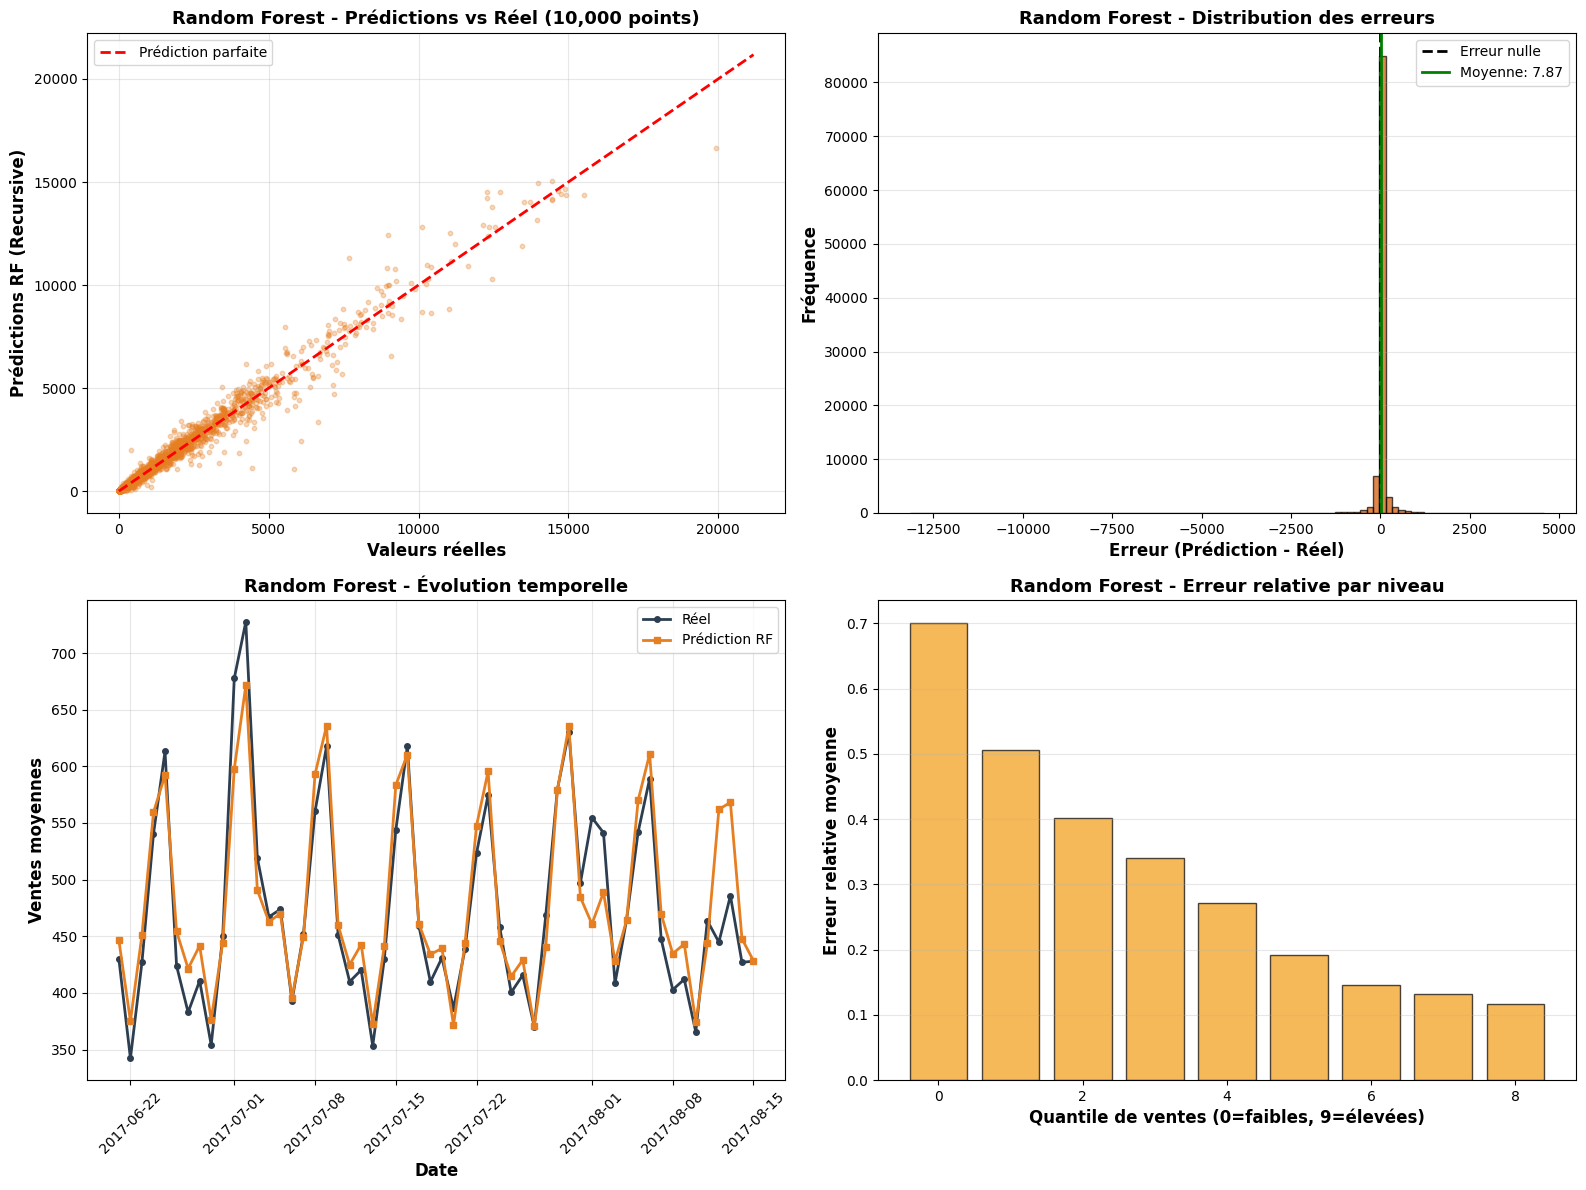

In [41]:
# ============================================================================
# GRAPHIQUES PRINCIPAUX - RANDOM FOREST
# ============================================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Scatter plot : Prédictions vs Réel
ax1 = axes[0, 0]
sample_size = min(10000, len(predictions_df_rf))
sample_idx = np.random.choice(len(predictions_df_rf), sample_size, replace=False)
sample_df = predictions_df_rf.iloc[sample_idx]

ax1.scatter(sample_df['y_true'], sample_df['y_pred'], alpha=0.3, s=10, color='#e67e22')
max_val = max(predictions_df_rf['y_true'].max(), predictions_df_rf['y_pred'].max())
ax1.plot([0, max_val], [0, max_val], 'r--', linewidth=2, label='Prédiction parfaite')
ax1.set_xlabel('Valeurs réelles', fontsize=12, fontweight='bold')
ax1.set_ylabel('Prédictions RF (Recursive)', fontsize=12, fontweight='bold')
ax1.set_title(f'Random Forest - Prédictions vs Réel ({sample_size:,} points)', fontsize=13, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Distribution des erreurs
ax2 = axes[0, 1]
errors_rf = predictions_df_rf['y_pred'] - predictions_df_rf['y_true']
ax2.hist(errors_rf, bins=100, color='#d35400', alpha=0.7, edgecolor='black')
ax2.axvline(x=0, color='black', linestyle='--', linewidth=2, label='Erreur nulle')
ax2.axvline(x=errors_rf.mean(), color='green', linestyle='-', linewidth=2, label=f'Moyenne: {errors_rf.mean():.2f}')
ax2.set_xlabel('Erreur (Prédiction - Réel)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Fréquence', fontsize=12, fontweight='bold')
ax2.set_title('Random Forest - Distribution des erreurs', fontsize=13, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

# 3. Évolution temporelle (moyenne quotidienne)
ax3 = axes[1, 0]
daily_agg_rf = predictions_df_rf.groupby('date').agg({
    'y_true': 'mean',
    'y_pred': 'mean'
}).reset_index()

ax3.plot(daily_agg_rf['date'], daily_agg_rf['y_true'], label='Réel', linewidth=2, color='#2c3e50', marker='o', markersize=4)
ax3.plot(daily_agg_rf['date'], daily_agg_rf['y_pred'], label='Prédiction RF', linewidth=2, color='#e67e22', marker='s', markersize=4)
ax3.set_xlabel('Date', fontsize=12, fontweight='bold')
ax3.set_ylabel('Ventes moyennes', fontsize=12, fontweight='bold')
ax3.set_title('Random Forest - Évolution temporelle', fontsize=13, fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3)
ax3.tick_params(axis='x', rotation=45)

# 4. Erreurs relatives par quantile de ventes
ax4 = axes[1, 1]
predictions_df_rf_copy = predictions_df_rf.copy()
predictions_df_rf_copy['abs_error'] = np.abs(predictions_df_rf_copy['y_pred'] - predictions_df_rf_copy['y_true'])
predictions_df_rf_copy['rel_error'] = predictions_df_rf_copy['abs_error'] / (predictions_df_rf_copy['y_true'] + 1)

# Créer des quantiles de ventes
predictions_df_rf_copy['sales_quantile'] = pd.qcut(predictions_df_rf_copy['y_true'], q=10, labels=False, duplicates='drop')
quantile_errors_rf = predictions_df_rf_copy.groupby('sales_quantile')['rel_error'].mean()

ax4.bar(quantile_errors_rf.index, quantile_errors_rf.values, color='#f39c12', alpha=0.7, edgecolor='black')
ax4.set_xlabel('Quantile de ventes (0=faibles, 9=élevées)', fontsize=12, fontweight='bold')
ax4.set_ylabel('Erreur relative moyenne', fontsize=12, fontweight='bold')
ax4.set_title('Random Forest - Erreur relative par niveau', fontsize=13, fontweight='bold')
ax4.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

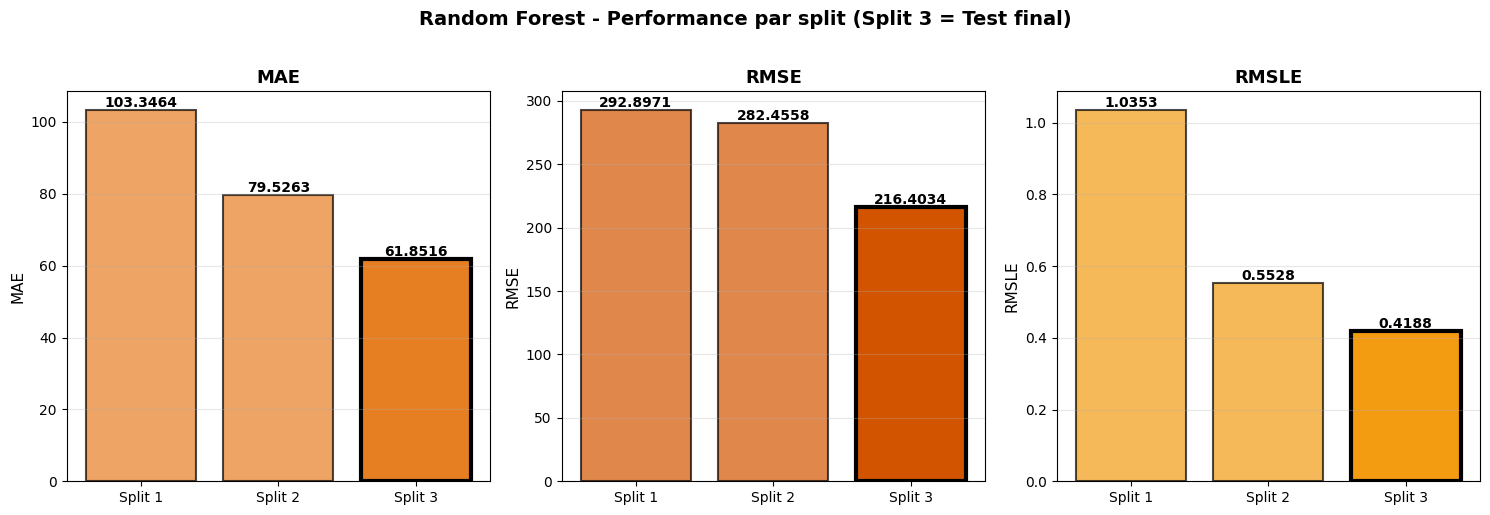

In [42]:
# ============================================================================
# GRAPHIQUE COMPARAISON PAR SPLIT - RANDOM FOREST
# ============================================================================

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
metrics_names = ['mae', 'rmse', 'rmsle']
colors = ['#e67e22', '#d35400', '#f39c12']

for idx, metric in enumerate(metrics_names):
    values = [res['metrics'][metric] for res in all_results_rf_recursive]
    labels = [f"Split {i+1}" for i in range(len(all_results_rf_recursive))]
    
    bars = axes[idx].bar(range(len(values)), values, color=colors[idx], alpha=0.7, edgecolor='black', linewidth=1.5)
    
    # Mettre en évidence le Split 3 (test final)
    bars[-1].set_edgecolor('black')
    bars[-1].set_linewidth(3)
    bars[-1].set_alpha(1.0)
    
    axes[idx].set_xticks(range(len(values)))
    axes[idx].set_xticklabels(labels)
    axes[idx].set_title(f'{metric.upper()}', fontsize=13, fontweight='bold')
    axes[idx].set_ylabel(f'{metric.upper()}', fontsize=11)
    axes[idx].grid(axis='y', alpha=0.3)
    
    # Ajouter les valeurs sur les barres
    for i, v in enumerate(values):
        axes[idx].text(i, v, f'{v:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.suptitle('Random Forest - Performance par split (Split 3 = Test final)', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

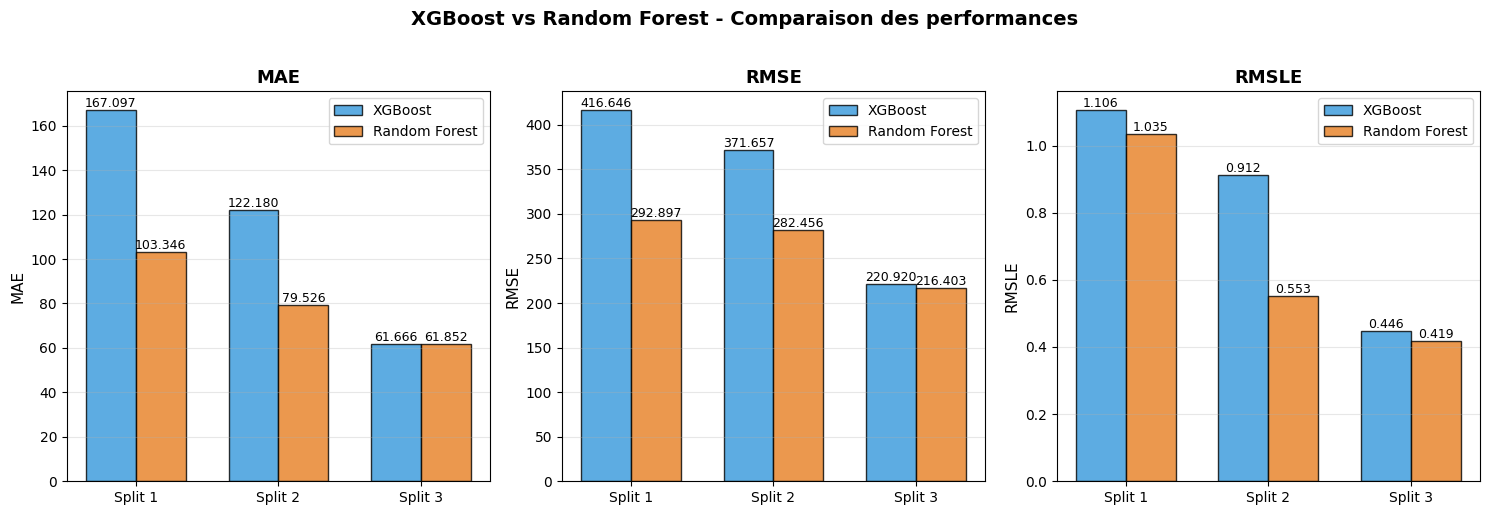

In [43]:
# ============================================================================
# COMPARAISON XGBoost vs Random Forest
# ============================================================================

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
metrics_names = ['mae', 'rmse', 'rmsle']

for idx, metric in enumerate(metrics_names):
    values_xgb = [res['metrics'][metric] for res in all_results_recursive]
    values_rf = [res['metrics'][metric] for res in all_results_rf_recursive]
    
    x = np.arange(len(all_results_recursive))
    width = 0.35
    
    bars1 = axes[idx].bar(x - width/2, values_xgb, width, label='XGBoost', color='#3498db', alpha=0.8, edgecolor='black')
    bars2 = axes[idx].bar(x + width/2, values_rf, width, label='Random Forest', color='#e67e22', alpha=0.8, edgecolor='black')
    
    axes[idx].set_xticks(x)
    axes[idx].set_xticklabels([f"Split {i+1}" for i in range(len(all_results_recursive))])
    axes[idx].set_title(f'{metric.upper()}', fontsize=13, fontweight='bold')
    axes[idx].set_ylabel(f'{metric.upper()}', fontsize=11)
    axes[idx].legend()
    axes[idx].grid(axis='y', alpha=0.3)
    
    # Ajouter les valeurs sur les barres
    for i, (v_xgb, v_rf) in enumerate(zip(values_xgb, values_rf)):
        axes[idx].text(i - width/2, v_xgb, f'{v_xgb:.3f}', ha='center', va='bottom', fontsize=9)
        axes[idx].text(i + width/2, v_rf, f'{v_rf:.3f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('XGBoost vs Random Forest - Comparaison des performances', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [47]:
# ============================================================================
# ANALYSE COMPLÉMENTAIRE - RANDOM FOREST
# ============================================================================

print("\n" + "="*80)
print("RANDOM FOREST - ANALYSE PAR STORE ET FAMILY")
print("="*80)

predictions_df_rf_analysis = predictions_df_rf.copy()
predictions_df_rf_analysis['abs_error'] = np.abs(predictions_df_rf_analysis['y_pred'] - predictions_df_rf_analysis['y_true'])

# Top/Worst Stores
store_errors_rf = predictions_df_rf_analysis.groupby('store_nbr').agg({
    'abs_error': 'mean',
    'y_true': 'count'
}).rename(columns={'abs_error': 'mae', 'y_true': 'nb_predictions'}).sort_values('mae')

print("\nTOP 5 STORES (meilleures prédictions):")
print(store_errors_rf.head(5).to_string())

print("\nWORST 5 STORES (pires prédictions):")
print(store_errors_rf.tail(5).to_string())

# Top/Worst Families
family_errors_rf = predictions_df_rf_analysis.groupby('family').agg({
    'abs_error': 'mean',
    'y_true': 'count'
}).rename(columns={'abs_error': 'mae', 'y_true': 'nb_predictions'}).sort_values('mae')

print("\nTOP 5 FAMILIES (meilleures prédictions):")
print(family_errors_rf.head(5).to_string())

print("\nWORST 5 FAMILIES (pires prédictions):")
print(family_errors_rf.tail(5).to_string())



RANDOM FOREST - ANALYSE PAR STORE ET FAMILY

TOP 5 STORES (meilleures prédictions):
                 mae  nb_predictions
store_nbr                           
35         27.935363            1848
10         28.904746            1848
23         29.904103            1848
15         30.380548            1848
12         31.364717            1848

WORST 5 STORES (pires prédictions):
                  mae  nb_predictions
store_nbr                            
49          90.939499            1848
46          97.669097            1848
45         102.809978            1848
47         111.096706            1848
44         123.582488            1848

TOP 5 FAMILIES (meilleures prédictions):
                      mae  nb_predictions
family                                   
BOOKS            0.242226            3024
BABY CARE        0.404108            3024
HOME APPLIANCES  0.595589            3024
HARDWARE         1.122388            3024
BEAUTY           2.253921            3024

WORST 5 FAMILIES

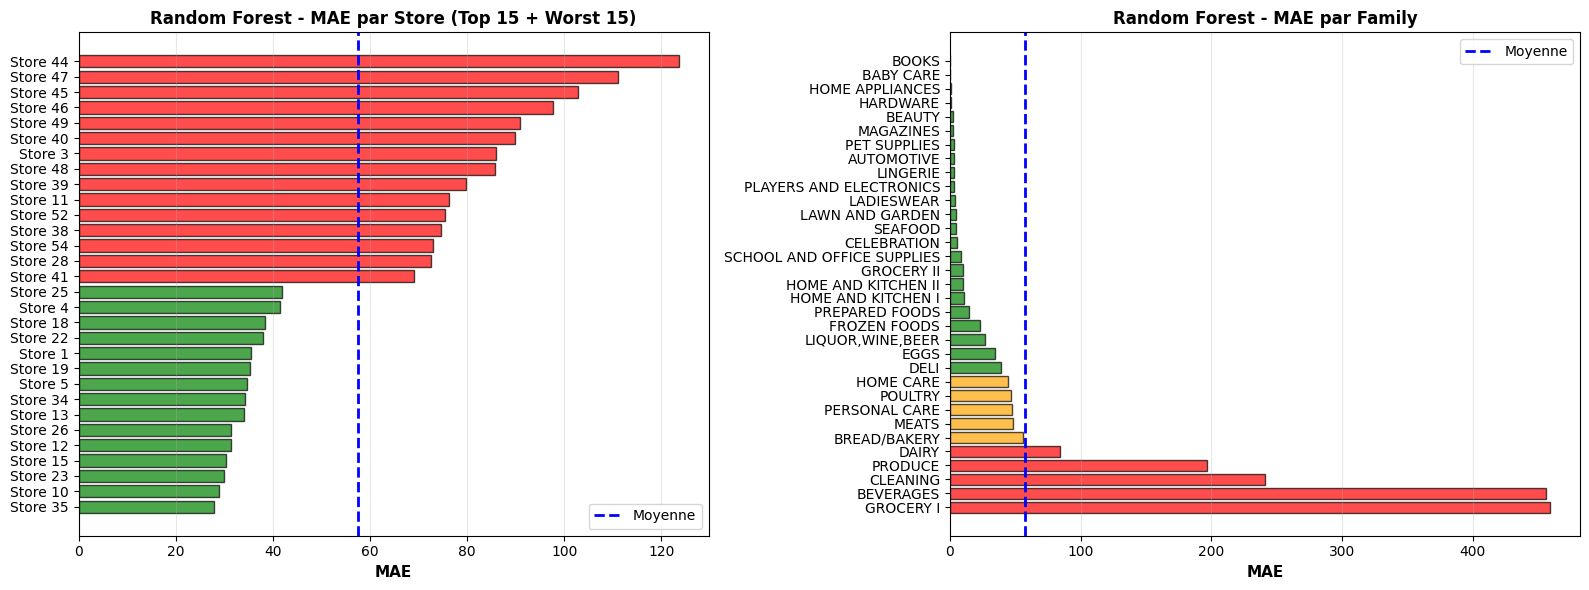

In [48]:
# ============================================================================
# VISUALISATION ERREURS PAR STORE ET FAMILY - RANDOM FOREST
# ============================================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Erreurs par Store (Top 15 et Worst 15)
ax1 = axes[0]
store_errors_rf_sorted = store_errors_rf.sort_values('mae')
top_stores_rf = store_errors_rf_sorted.head(15)
worst_stores_rf = store_errors_rf_sorted.tail(15)
stores_to_plot_rf = pd.concat([top_stores_rf, worst_stores_rf])

colors_stores_rf = ['green' if i < 15 else 'red' for i in range(len(stores_to_plot_rf))]
ax1.barh(range(len(stores_to_plot_rf)), stores_to_plot_rf['mae'], color=colors_stores_rf, alpha=0.7, edgecolor='black')
ax1.set_yticks(range(len(stores_to_plot_rf)))
ax1.set_yticklabels([f"Store {s}" for s in stores_to_plot_rf.index])
ax1.set_xlabel('MAE', fontsize=11, fontweight='bold')
ax1.set_title('Random Forest - MAE par Store (Top 15 + Worst 15)', fontsize=12, fontweight='bold')
ax1.grid(axis='x', alpha=0.3)
ax1.axvline(x=store_errors_rf['mae'].mean(), color='blue', linestyle='--', linewidth=2, label='Moyenne')
ax1.legend()

# Erreurs par Family
ax2 = axes[1]
family_errors_rf_sorted = family_errors_rf.sort_values('mae', ascending=False)
colors_family_rf = ['red' if i < 5 else 'orange' if i < 10 else 'green' for i in range(len(family_errors_rf_sorted))]

ax2.barh(range(len(family_errors_rf_sorted)), family_errors_rf_sorted['mae'], color=colors_family_rf, alpha=0.7, edgecolor='black')
ax2.set_yticks(range(len(family_errors_rf_sorted)))
ax2.set_yticklabels(family_errors_rf_sorted.index)
ax2.set_xlabel('MAE', fontsize=11, fontweight='bold')
ax2.set_title('Random Forest - MAE par Family', fontsize=12, fontweight='bold')
ax2.grid(axis='x', alpha=0.3)
ax2.axvline(x=family_errors_rf['mae'].mean(), color='blue', linestyle='--', linewidth=2, label='Moyenne')
ax2.legend()

plt.tight_layout()
plt.show()


RANDOM FOREST - FEATURE IMPORTANCE

TOP 20 FEATURES PAR IMPORTANCE
                      feature  importance
           scaled_sales_lag_7    0.166704
        scaled_rolling_mean_7    0.166054
          scaled_sales_lag_14    0.132372
           scaled_sales_lag_1    0.114611
       scaled_rolling_mean_28    0.095534
          scaled_sales_lag_28    0.064790
           scaled_sales_lag_2    0.063018
          scaled_sales_lag_56    0.052147
           scaled_sales_lag_3    0.049658
         scaled_rolling_std_7    0.037309
         scaled_sales_lag_364    0.015034
   scaled_catboost_enc_family    0.007928
           scaled_onpromotion    0.007290
               scaled_day_sin    0.006895
scaled_catboost_enc_store_nbr    0.004931
     scaled_days_to_christmas    0.003847
  scaled_catboost_enc_cluster    0.003364
               scaled_day_cos    0.001499
      scaled_oil_price_lag_8w    0.001313
     scaled_catboost_enc_city    0.001302


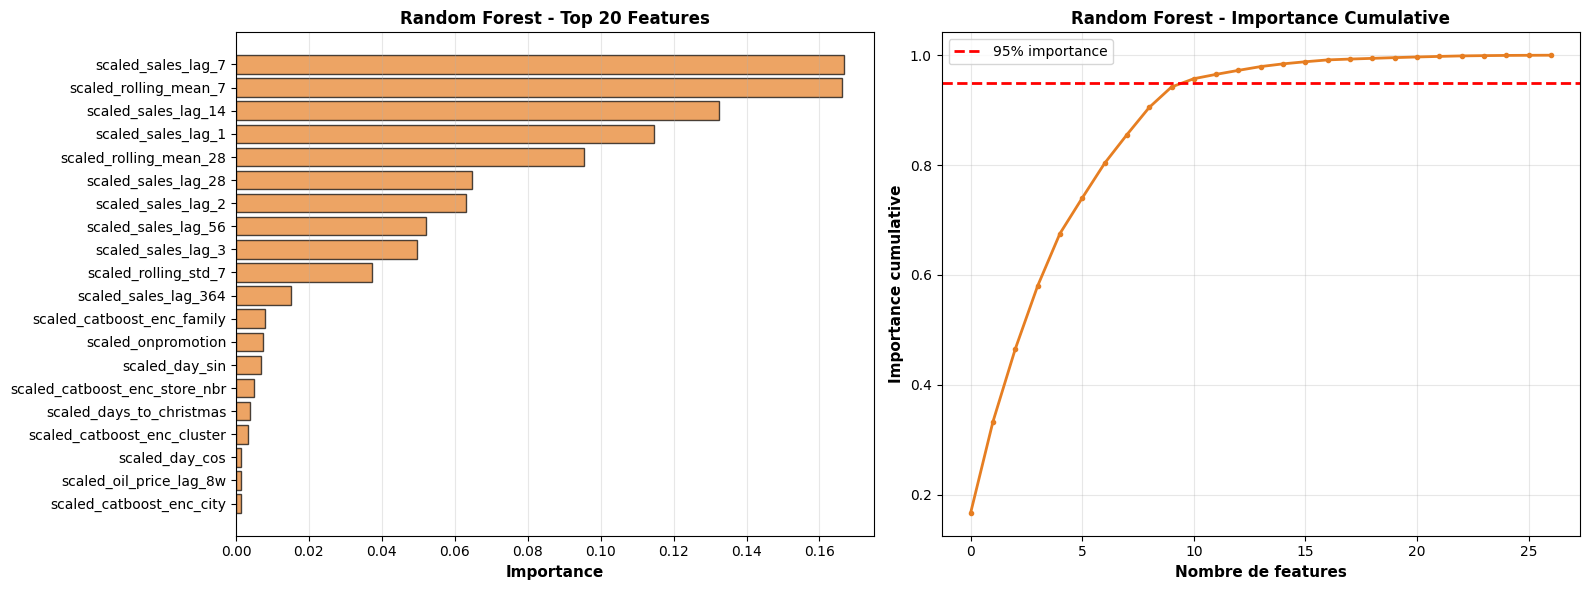


Nombre de features pour 95% de l'importance: 11/27


In [46]:
# ============================================================================
# FEATURE IMPORTANCE NATIVE - RANDOM FOREST
# ============================================================================

print("\n" + "="*80)
print("RANDOM FOREST - FEATURE IMPORTANCE")
print("="*80)

# Récupérer le modèle Random Forest
model_rf = split3_result_rf['model']
features_rf = split3_result_rf['features']

# Feature importance native
feature_importance_rf = model_rf.feature_importances_

# Créer DataFrame
importance_df_rf = pd.DataFrame({
    'feature': features_rf,
    'importance': feature_importance_rf
}).sort_values('importance', ascending=False)

print("\nTOP 20 FEATURES PAR IMPORTANCE")
print(importance_df_rf.head(20).to_string(index=False))

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar plot - Top 20
ax1 = axes[0]
top_20_rf = importance_df_rf.head(20)
ax1.barh(range(len(top_20_rf)), top_20_rf['importance'], color='#e67e22', alpha=0.7, edgecolor='black')
ax1.set_yticks(range(len(top_20_rf)))
ax1.set_yticklabels(top_20_rf['feature'])
ax1.invert_yaxis()
ax1.set_xlabel('Importance', fontsize=11, fontweight='bold')
ax1.set_title('Random Forest - Top 20 Features', fontsize=12, fontweight='bold')
ax1.grid(axis='x', alpha=0.3)

# Graphique cumulé
ax2 = axes[1]
cumulative_importance = np.cumsum(importance_df_rf['importance'])
ax2.plot(range(len(cumulative_importance)), cumulative_importance, linewidth=2, color='#e67e22', marker='o', markersize=3)
ax2.axhline(y=0.95, color='red', linestyle='--', linewidth=2, label='95% importance')
ax2.set_xlabel('Nombre de features', fontsize=11, fontweight='bold')
ax2.set_ylabel('Importance cumulative', fontsize=11, fontweight='bold')
ax2.set_title('Random Forest - Importance Cumulative', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

# Nombre de features pour 95% importance
n_features_95 = np.argmax(cumulative_importance >= 0.95) + 1
print(f"\nNombre de features pour 95% de l'importance: {n_features_95}/{len(features_rf)}")

# Stacking Ridge XGB & RF

In [52]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold
import xgboost as xgb
import numpy as np
import pandas as pd
import warnings

def train_and_evaluate_split_stacking_oof(train_df, test_df, split_config, 
                                          rf_hyperparams=None, use_gpu=False,
                                          ridge_alpha=1.0, n_folds=5):
    """
    Stacking Ridge avec Out-of-Fold predictions pour éviter le sur-ajustement.
    Les prédictions sont clippées à 0.
    
    Parameters
    ----------
    train_df : pd.DataFrame
        Dataframe d'entrainement complet
    test_df : pd.DataFrame
        Dataframe de test final
    split_config : dict
        Configuration du split (dates, nom, etc.)
    rf_hyperparams : dict, optional
        Hyperparametres Random Forest personnalises
    use_gpu : bool
        Utiliser le GPU pour XGBoost
    ridge_alpha : float
        Paramètre de régularisation pour Ridge
    n_folds : int
        Nombre de folds pour la validation croisée
    
    Returns
    -------
    dict
        Dictionnaire contenant les resultats, metriques et predictions
    """
    
    warnings.filterwarnings('ignore')
    
    # Creation des ensembles train et test pour ce split
    if split_config['use_real_test']:
        train_split = train_df.copy()
        test_split = test_df.copy()
    else:
        train_split = train_df[train_df['date'] <= split_config['train_end']].copy()
        test_split = train_df[
            (train_df['date'] >= split_config['test_start']) & 
            (train_df['date'] <= split_config['test_end'])
        ].copy()
    
    if len(test_split) == 0:
        return None
    
    print(f"Train: {train_split['date'].min()} -> {train_split['date'].max()}")
    print(f"Test:  {test_split['date'].min()} -> {test_split['date'].max()}")
    print(f"GPU:   {'Activé ✓' if use_gpu else 'Désactivé'}")
    print(f"Folds: {n_folds}")
    
    # ========================================================================
    # PHASE 1: PREPARATION INITIALE
    # ========================================================================
    
    print("\n[1/6] Feature engineering sur train...")
    train_processed = apply_catboost_encoding(
        train_split,
        cols=['store_nbr', 'family', 'city', 'cluster'],
        target='sales',
        nb_previous_days_to_ignore=56,
        fill_first_na=True
    )
    
    train_scaled, scaler = apply_robust_scaler(
        train_processed,
        exclude_cols=['id', 'date', 'store_nbr', 'family', 'city', 'state', 
                      'store_type', 'cluster', 'sales', 'log_sales',
                      'is_holiday_local', 'is_holiday_regional', 
                      'is_holiday_national', 'is_store_closed', 
                      'is_weekend', 'is_payday', 'is_earthquake_impact',
                      'is_family_unactive', 'holiday_type'],
        drop_original=True
    )
    
    # Definition des features
    exclude_from_features = [
        'id', 'date', 'sales', 'log_sales',
        'store_nbr', 'family', 'city', 'state', 'store_type', 'cluster', 'holiday_type'
    ]

    features = []
    for col in train_scaled.columns:
        if col in exclude_from_features:
            continue
        if train_scaled[col].dtype in ['int16', 'int32', 'int64', 'float16', 'float32', 'float64', 'bool']:
            features.append(col)
    
    X_train = train_scaled[features]
    y_train = train_scaled['sales']
    
    print(f"Nombre de features: {len(features)}")
    
    # ========================================================================
    # PHASE 2: GENERATION DES OUT-OF-FOLD PREDICTIONS
    # ========================================================================
    
    print(f"\n[2/6] Génération des OOF predictions ({n_folds} folds)...")
    
    # Initialiser les hyperparamètres RF si non fournis
    if rf_hyperparams is None:
        rf_hyperparams = {
            'n_estimators': 200,
            'max_depth': 20,
            'min_samples_split': 10,
            'min_samples_leaf': 5,
            'max_features': 'sqrt',
            'bootstrap': True,
            'n_jobs': -1,
            'random_state': 42
        }
    
    # Initialiser les arrays pour OOF predictions
    rf_oof_preds = np.zeros(len(X_train))
    xgb_oof_preds = np.zeros(len(X_train))
    
    # KFold avec shuffle
    kf = KFold(n_splits=n_folds, shuffle=True, random_state=42)
    
    fold_scores = []
    
    for fold_idx, (train_idx, val_idx) in enumerate(kf.split(X_train)):
        print(f"\n  → Fold {fold_idx + 1}/{n_folds}")
        
        # Séparer train et validation pour ce fold
        X_fold_train = X_train.iloc[train_idx]
        y_fold_train = y_train.iloc[train_idx]
        X_fold_val = X_train.iloc[val_idx]
        y_fold_val = y_train.iloc[val_idx]
        
        # --- Random Forest ---
        print(f"    Training RF...")
        rf_fold_params = rf_hyperparams.copy()
        rf_fold_params['random_state'] = 42 + fold_idx
        rf_fold = RandomForestRegressor(**rf_fold_params)
        rf_fold.fit(X_fold_train, y_fold_train)
        
        # Prédictions OOF pour RF
        rf_val_preds = rf_fold.predict(X_fold_val)
        rf_val_preds = np.maximum(rf_val_preds, 0)  # Clipper à 0
        rf_oof_preds[val_idx] = rf_val_preds
        
        # --- XGBoost ---
        print(f"    Training XGB...")
        if use_gpu:
            xgb_fold = xgb.XGBRegressor(
                objective='reg:squarederror',
                max_depth=8,
                learning_rate=0.05,
                n_estimators=500,
                subsample=0.8,
                colsample_bytree=0.8,
                min_child_weight=5,
                random_state=42 + fold_idx,
                tree_method='hist',
                device='cuda',
                n_jobs=1
            )
        else:
            xgb_fold = xgb.XGBRegressor(
                objective='reg:squarederror',
                max_depth=8,
                learning_rate=0.05,
                n_estimators=500,
                subsample=0.8,
                colsample_bytree=0.8,
                min_child_weight=5,
                random_state=42 + fold_idx,
                tree_method='hist',
                device='cpu',
                n_jobs=-1
            )
        
        xgb_fold.fit(X_fold_train, y_fold_train, verbose=False)
        
        # Prédictions OOF pour XGB
        xgb_val_preds = xgb_fold.predict(X_fold_val)
        xgb_val_preds = np.maximum(xgb_val_preds, 0)  # Clipper à 0
        xgb_oof_preds[val_idx] = xgb_val_preds
        
        # Calculer les scores du fold
        from sklearn.metrics import mean_squared_error, mean_absolute_error
        
        rf_rmse = np.sqrt(mean_squared_error(y_fold_val, rf_val_preds))
        xgb_rmse = np.sqrt(mean_squared_error(y_fold_val, xgb_val_preds))
        
        fold_scores.append({
            'fold': fold_idx + 1,
            'rf_rmse': rf_rmse,
            'xgb_rmse': xgb_rmse
        })
        
        print(f"    ✓ RF RMSE: {rf_rmse:.4f} | XGB RMSE: {xgb_rmse:.4f}")
    
    # Scores moyens OOF
    rf_oof_rmse = np.sqrt(mean_squared_error(y_train, rf_oof_preds))
    xgb_oof_rmse = np.sqrt(mean_squared_error(y_train, xgb_oof_preds))
    
    print(f"\n  ✓ OOF RMSE moyen:")
    print(f"    RF:  {rf_oof_rmse:.4f}")
    print(f"    XGB: {xgb_oof_rmse:.4f}")
    
    # ========================================================================
    # PHASE 3: ENTRAINEMENT DU META-MODELE RIDGE SUR OOF
    # ========================================================================
    
    print(f"\n[3/6] Entraînement Ridge sur OOF predictions (alpha={ridge_alpha})...")
    
    # Créer les meta-features à partir des OOF predictions
    meta_features_train = np.column_stack([rf_oof_preds, xgb_oof_preds])
    
    # Entraîner Ridge
    ridge_model = Ridge(alpha=ridge_alpha, random_state=42)
    ridge_model.fit(meta_features_train, y_train)
    
    # Prédictions du stacking sur OOF
    stacking_oof_preds = ridge_model.predict(meta_features_train)
    stacking_oof_preds = np.maximum(stacking_oof_preds, 0)
    stacking_oof_rmse = np.sqrt(mean_squared_error(y_train, stacking_oof_preds))
    
    print(f"    ✓ Coefficients Ridge: RF={ridge_model.coef_[0]:.4f}, XGB={ridge_model.coef_[1]:.4f}")
    print(f"    ✓ Intercept: {ridge_model.intercept_:.4f}")
    print(f"    ✓ Stacking OOF RMSE: {stacking_oof_rmse:.4f}")
    
    # Vérifier si le stacking améliore
    best_individual_rmse = min(rf_oof_rmse, xgb_oof_rmse)
    improvement = ((best_individual_rmse - stacking_oof_rmse) / best_individual_rmse) * 100
    
    if improvement > 0:
        print(f"    ✓ Amélioration: +{improvement:.2f}% vs meilleur modèle seul")
    else:
        print(f"    ⚠ Dégradation: {improvement:.2f}% vs meilleur modèle seul")
    
    # ========================================================================
    # PHASE 4: RE-ENTRAINEMENT DES MODELES DE BASE SUR TOUT LE TRAIN
    # ========================================================================
    
    print(f"\n[4/6] Ré-entraînement des modèles sur l'ensemble du train...")
    
    # --- Random Forest final ---
    print("  → Random Forest...")
    rf_model = RandomForestRegressor(**rf_hyperparams)
    rf_model.fit(X_train, y_train)
    print("    ✓ Random Forest entraîné")
    
    # --- XGBoost final ---
    print(f"  → XGBoost {'sur GPU' if use_gpu else 'sur CPU'}...")
    if use_gpu:
        xgb_model = xgb.XGBRegressor(
            objective='reg:squarederror',
            max_depth=8,
            learning_rate=0.05,
            n_estimators=500,
            subsample=0.8,
            colsample_bytree=0.8,
            min_child_weight=5,
            random_state=42,
            tree_method='hist',
            device='cuda',
            n_jobs=1
        )
    else:
        xgb_model = xgb.XGBRegressor(
            objective='reg:squarederror',
            max_depth=8,
            learning_rate=0.05,
            n_estimators=500,
            subsample=0.8,
            colsample_bytree=0.8,
            min_child_weight=5,
            random_state=42,
            tree_method='hist',
            device='cpu',
            n_jobs=-1
        )
    
    xgb_model.fit(X_train, y_train, verbose=False)
    print("    ✓ XGBoost entraîné")
    
    # ========================================================================
    # PHASE 5: PREPARATION DES DONNEES TEST
    # ========================================================================
    
    print("\n[5/6] Préparation des données test (encodings UNE SEULE FOIS)...")
    
    # Combiner train et test
    combined_data = pd.concat([train_split, test_split], ignore_index=True).copy()
    combined_data = combined_data.sort_values(['store_nbr', 'family', 'date']).reset_index(drop=True)
    
    # Appliquer CatBoost encoding UNE FOIS
    combined_encoded = apply_catboost_encoding(
        combined_data,
        cols=['store_nbr', 'family', 'city', 'cluster'],
        target='sales',
        nb_previous_days_to_ignore=56,
        fill_first_na=True
    )
    
    # Appliquer le scaler
    combined_scaled = combined_encoded.copy()
    scaled_cols_in_train = [c for c in train_scaled.columns if c.startswith('scaled_')]
    original_cols_that_were_scaled = [c.replace('scaled_', '') for c in scaled_cols_in_train]
    cols_to_scale = [c for c in original_cols_that_were_scaled if c in combined_encoded.columns]
    
    if len(cols_to_scale) > 0:
        scaled_values = scaler.transform(combined_encoded[cols_to_scale])
        scaled_col_names = [f'scaled_{c}' for c in cols_to_scale]
        combined_scaled[scaled_col_names] = scaled_values
        combined_scaled.drop(columns=cols_to_scale, inplace=True)
    
    print("✓ Données préparées")
    
    # ========================================================================
    # PHASE 6: PREDICTION RECURSIVE AVEC STACKING
    # ========================================================================
    
    test_dates = sorted(test_split['date'].unique())
    print(f"\n[6/6] Prédiction récursive avec stacking sur {len(test_dates)} jours...")
    
    predictions_list = []
    n_clipped_rf = 0
    n_clipped_xgb = 0
    n_clipped_final = 0
    
    for day_idx, current_date in enumerate(test_dates):
        # Extraire les données du jour
        day_mask = combined_scaled['date'] == current_date
        day_data = combined_scaled[day_mask].copy()
        
        if len(day_data) == 0:
            continue
        
        # Prédire avec les deux modèles de base
        X_day = day_data[features]
        
        rf_pred_day = rf_model.predict(X_day)
        xgb_pred_day = xgb_model.predict(X_day)
        
        # Clipper les prédictions de base
        n_clipped_rf += (rf_pred_day < 0).sum()
        n_clipped_xgb += (xgb_pred_day < 0).sum()
        
        rf_pred_day = np.maximum(rf_pred_day, 0)
        xgb_pred_day = np.maximum(xgb_pred_day, 0)
        
        # Créer les meta-features
        meta_features_day = np.column_stack([rf_pred_day, xgb_pred_day])
        
        # Prédiction finale avec Ridge
        y_pred_day = ridge_model.predict(meta_features_day)
        
        # Clipper la prédiction finale
        n_clipped_final += (y_pred_day < 0).sum()
        y_pred_day = np.maximum(y_pred_day, 0)
        
        # Mettre à jour les sales
        day_indices = combined_scaled[day_mask].index
        combined_scaled.loc[day_indices, 'sales'] = y_pred_day
        
        # Mettre à jour les lags pour les jours futurs
        for idx, (store, family) in enumerate(zip(day_data['store_nbr'], day_data['family'])):
            pred_value = y_pred_day[idx]
            
            future_mask = (
                (combined_scaled['store_nbr'] == store) &
                (combined_scaled['family'] == family) &
                (combined_scaled['date'] > current_date)
            )
            
            if future_mask.sum() > 0:
                future_indices = combined_scaled[future_mask].index
                
                for future_idx in future_indices:
                    future_date = combined_scaled.loc[future_idx, 'date']
                    days_diff = (future_date - current_date).days
                    
                    lag_mapping = {
                        1: 'sales_lag_1',
                        2: 'sales_lag_2',
                        3: 'sales_lag_3',
                        7: 'sales_lag_7',
                        14: 'sales_lag_14',
                        28: 'sales_lag_28',
                        56: 'sales_lag_56'
                    }
                    
                    if days_diff in lag_mapping:
                        lag_col = lag_mapping[days_diff]
                        if lag_col in combined_scaled.columns:
                            combined_scaled.loc[future_idx, lag_col] = pred_value
                            
                            scaled_lag_col = f'scaled_{lag_col}'
                            if scaled_lag_col in features:
                                col_idx = list(original_cols_that_were_scaled).index(lag_col) if lag_col in original_cols_that_were_scaled else None
                                if col_idx is not None:
                                    combined_scaled.loc[future_idx, scaled_lag_col] = scaled_values[future_idx, col_idx]
                    
                    if days_diff <= 7 and 'rolling_mean_7' in combined_scaled.columns:
                        past_7_mask = (
                            (combined_scaled['store_nbr'] == store) &
                            (combined_scaled['family'] == family) &
                            (combined_scaled['date'] >= future_date - pd.Timedelta(days=7)) &
                            (combined_scaled['date'] < future_date)
                        )
                        past_7_sales = combined_scaled.loc[past_7_mask, 'sales']
                        if len(past_7_sales) > 0:
                            new_rolling_mean = past_7_sales.mean()
                            combined_scaled.loc[future_idx, 'rolling_mean_7'] = new_rolling_mean
        
        # Stocker les prédictions
        day_results = pd.DataFrame({
            'date': day_data['date'].values,
            'store_nbr': day_data['store_nbr'].values,
            'family': day_data['family'].values,
            'y_pred_rf': rf_pred_day,
            'y_pred_xgb': xgb_pred_day,
            'y_pred': y_pred_day
        })
        
        predictions_list.append(day_results)
        
        if (day_idx + 1) % 7 == 0:
            print(f"  ✓ {day_idx + 1}/{len(test_dates)} jours traités")
    
    # Afficher clipping
    print(f"\nClipping des prédictions:")
    print(f"  RF:    {n_clipped_rf} prédictions négatives clippées")
    print(f"  XGB:   {n_clipped_xgb} prédictions négatives clippées")
    print(f"  Final: {n_clipped_final} prédictions négatives clippées")
    
    # Combiner prédictions
    all_predictions = pd.concat(predictions_list, ignore_index=True)
    
    # Récupérer vraies valeurs
    test_split_sorted = test_split.sort_values(['date', 'store_nbr', 'family']).reset_index(drop=True)
    all_predictions = all_predictions.merge(
        test_split_sorted[['date', 'store_nbr', 'family', 'sales', 'is_store_closed', 'is_family_unactive']],
        on=['date', 'store_nbr', 'family'],
        how='left'
    )
    all_predictions = all_predictions.rename(columns={'sales': 'y_true'})
    
    # Evaluation
    print("\n[Evaluation] Calcul des métriques...")
    metrics = evaluate_model(
        y_true=all_predictions['y_true'].values,
        y_pred=all_predictions['y_pred'].values,
        is_store_closed=all_predictions['is_store_closed'].values,
        is_family_unactive=all_predictions['is_family_unactive'].values
    )
    
    # Métriques pour RF et XGB individuellement
    metrics_rf = evaluate_model(
        y_true=all_predictions['y_true'].values,
        y_pred=all_predictions['y_pred_rf'].values,
        is_store_closed=all_predictions['is_store_closed'].values,
        is_family_unactive=all_predictions['is_family_unactive'].values
    )
    
    metrics_xgb = evaluate_model(
        y_true=all_predictions['y_true'].values,
        y_pred=all_predictions['y_pred_xgb'].values,
        is_store_closed=all_predictions['is_store_closed'].values,
        is_family_unactive=all_predictions['is_family_unactive'].values
    )
    
    results = {
        'split_name': split_config['name'] + ' (Stacking OOF)',
        'train_size': len(train_split),
        'test_size': len(test_split),
        'train_start': train_split['date'].min(),
        'train_end': train_split['date'].max(),
        'test_start': test_split['date'].min(),
        'test_end': test_split['date'].max(),
        'metrics': metrics,
        'metrics_rf': metrics_rf,
        'metrics_xgb': metrics_xgb,
        'oof_scores': {
            'rf_rmse': rf_oof_rmse,
            'xgb_rmse': xgb_oof_rmse,
            'stacking_rmse': stacking_oof_rmse,
            'improvement': improvement
        },
        'fold_scores': fold_scores,
        'rf_model': rf_model,
        'xgb_model': xgb_model,
        'ridge_model': ridge_model,
        'ridge_coefs': {
            'rf': ridge_model.coef_[0],
            'xgb': ridge_model.coef_[1],
            'intercept': ridge_model.intercept_
        },
        'features': features,
        'scaler': scaler,
        'predictions': all_predictions,
        'use_gpu': use_gpu,
        'ridge_alpha': ridge_alpha,
        'n_folds': n_folds,
        'n_clipped': {
            'rf': n_clipped_rf,
            'xgb': n_clipped_xgb,
            'final': n_clipped_final
        }
    }
    
    return results

In [53]:
# ============================================================================
# EXECUTION STACKING OOF
# ============================================================================

print("="*80)
print("PREDICTION RECURSIVE - STACKING OOF (RF + XGB)")
print("="*80)

all_results_stacking_oof = []

for split_config in SPLITS:
    print(f"\n{'='*80}")
    print(f"{split_config['name']}")
    print(f"{'='*80}")
    
    result = train_and_evaluate_split_stacking_oof(
        train_df=train,
        test_df=test,
        split_config=split_config,
        use_gpu=True,
        ridge_alpha=1.0,
        n_folds=5  # 5-fold cross-validation
    )
    
    if result is not None:
        all_results_stacking_oof.append(result)
        print(f"\n✓ Résultats:")
        print(f"\n  OOF Scores (validation croisée):")
        print(f"    RF:       {result['oof_scores']['rf_rmse']:.4f}")
        print(f"    XGB:      {result['oof_scores']['xgb_rmse']:.4f}")
        print(f"    Stacking: {result['oof_scores']['stacking_rmse']:.4f}")
        print(f"    Amélioration: {result['oof_scores']['improvement']:.2f}%")
        
        print(f"\n  Test Final:")
        print(f"    RF   - RMSLE: {result['metrics_rf']['rmsle']:.4f}")
        print(f"    XGB  - RMSLE: {result['metrics_xgb']['rmsle']:.4f}")
        print(f"    Stack- RMSLE: {result['metrics']['rmsle']:.4f}")
        
        print(f"\n  Poids Ridge (OOF):")
        print(f"    RF:  {result['ridge_coefs']['rf']:.4f}")
        print(f"    XGB: {result['ridge_coefs']['xgb']:.4f}")

PREDICTION RECURSIVE - STACKING OOF (RF + XGB)

Split 1 (2 ans)
Train: 2013-01-01 00:00:00 -> 2015-01-01 00:00:00
Test:  2015-01-02 00:00:00 -> 2015-02-27 00:00:00
GPU:   Activé ✓
Folds: 5

[1/6] Feature engineering sur train...
Variable 'store_nbr': 54 categories -> Dynamic alpha: 20.04
3024 NaN found in catboost_enc_store_nbr before filling.
Filled NaN in catboost_enc_store_nbr with global mean: 269.3495178222656
Variable 'family': 33 categories -> Dynamic alpha: 17.63
1848 NaN found in catboost_enc_family before filling.
Filled NaN in catboost_enc_family with global mean: 269.3495178222656
Variable 'city': 22 categories -> Dynamic alpha: 15.68
1232 NaN found in catboost_enc_city before filling.
Filled NaN in catboost_enc_city with global mean: 269.3495178222656
Variable 'cluster': 17 categories -> Dynamic alpha: 14.45
952 NaN found in catboost_enc_cluster before filling.
Filled NaN in catboost_enc_cluster with global mean: 269.3495178222656
27 colonnes créées avec préfixe 'scaled_' 

In [55]:
# ============================================================================
# COMPARAISON OOF vs NAIVE
# ============================================================================

print("\n" + "="*120)
print("COMPARAISON STACKING OOF vs VERSION NAIVE")
print("="*120)

comparison_methods = []

for res in all_results_stacking_oof:
    split_base = res['split_name'].replace(' (Stacking OOF)', '')
    
    comparison_methods.append({
        'Split': split_base,
        'Method': 'OOF Stacking',
        'RMSLE': f"{res['metrics']['rmsle']:.4f}",
        'OOF_Improvement': f"{res['oof_scores']['improvement']:.2f}%",
        'RF_Weight': f"{res['ridge_coefs']['rf']:.3f}",
        'XGB_Weight': f"{res['ridge_coefs']['xgb']:.3f}"
    })

comparison_df = pd.DataFrame(comparison_methods)
print(comparison_df.to_string(index=False))

# Analyse de stabilite
rmsle_oof = [res['metrics']['rmsle'] for res in all_results_stacking_oof]
print(f"\nAnalyse de stabilité (Stacking OOF):")
print(f"  RMSLE moyen: {np.mean(rmsle_oof):.4f}")
print(f"  Ecart-type:  {np.std(rmsle_oof):.4f}")
print(f"  Min-Max:     [{min(rmsle_oof):.4f}, {max(rmsle_oof):.4f}]")


COMPARAISON STACKING OOF vs VERSION NAIVE
          Split       Method  RMSLE OOF_Improvement RF_Weight XGB_Weight
Split 1 (2 ans) OOF Stacking 1.0961           0.06%     0.061      0.941
Split 2 (3 ans) OOF Stacking 0.9731           0.01%    -0.008      1.010
Split 3 (Final) OOF Stacking 0.4651           0.02%     0.036      0.966

Analyse de stabilité (Stacking OOF):
  RMSLE moyen: 0.8448
  Ecart-type:  0.2731
  Min-Max:     [0.4651, 1.0961]


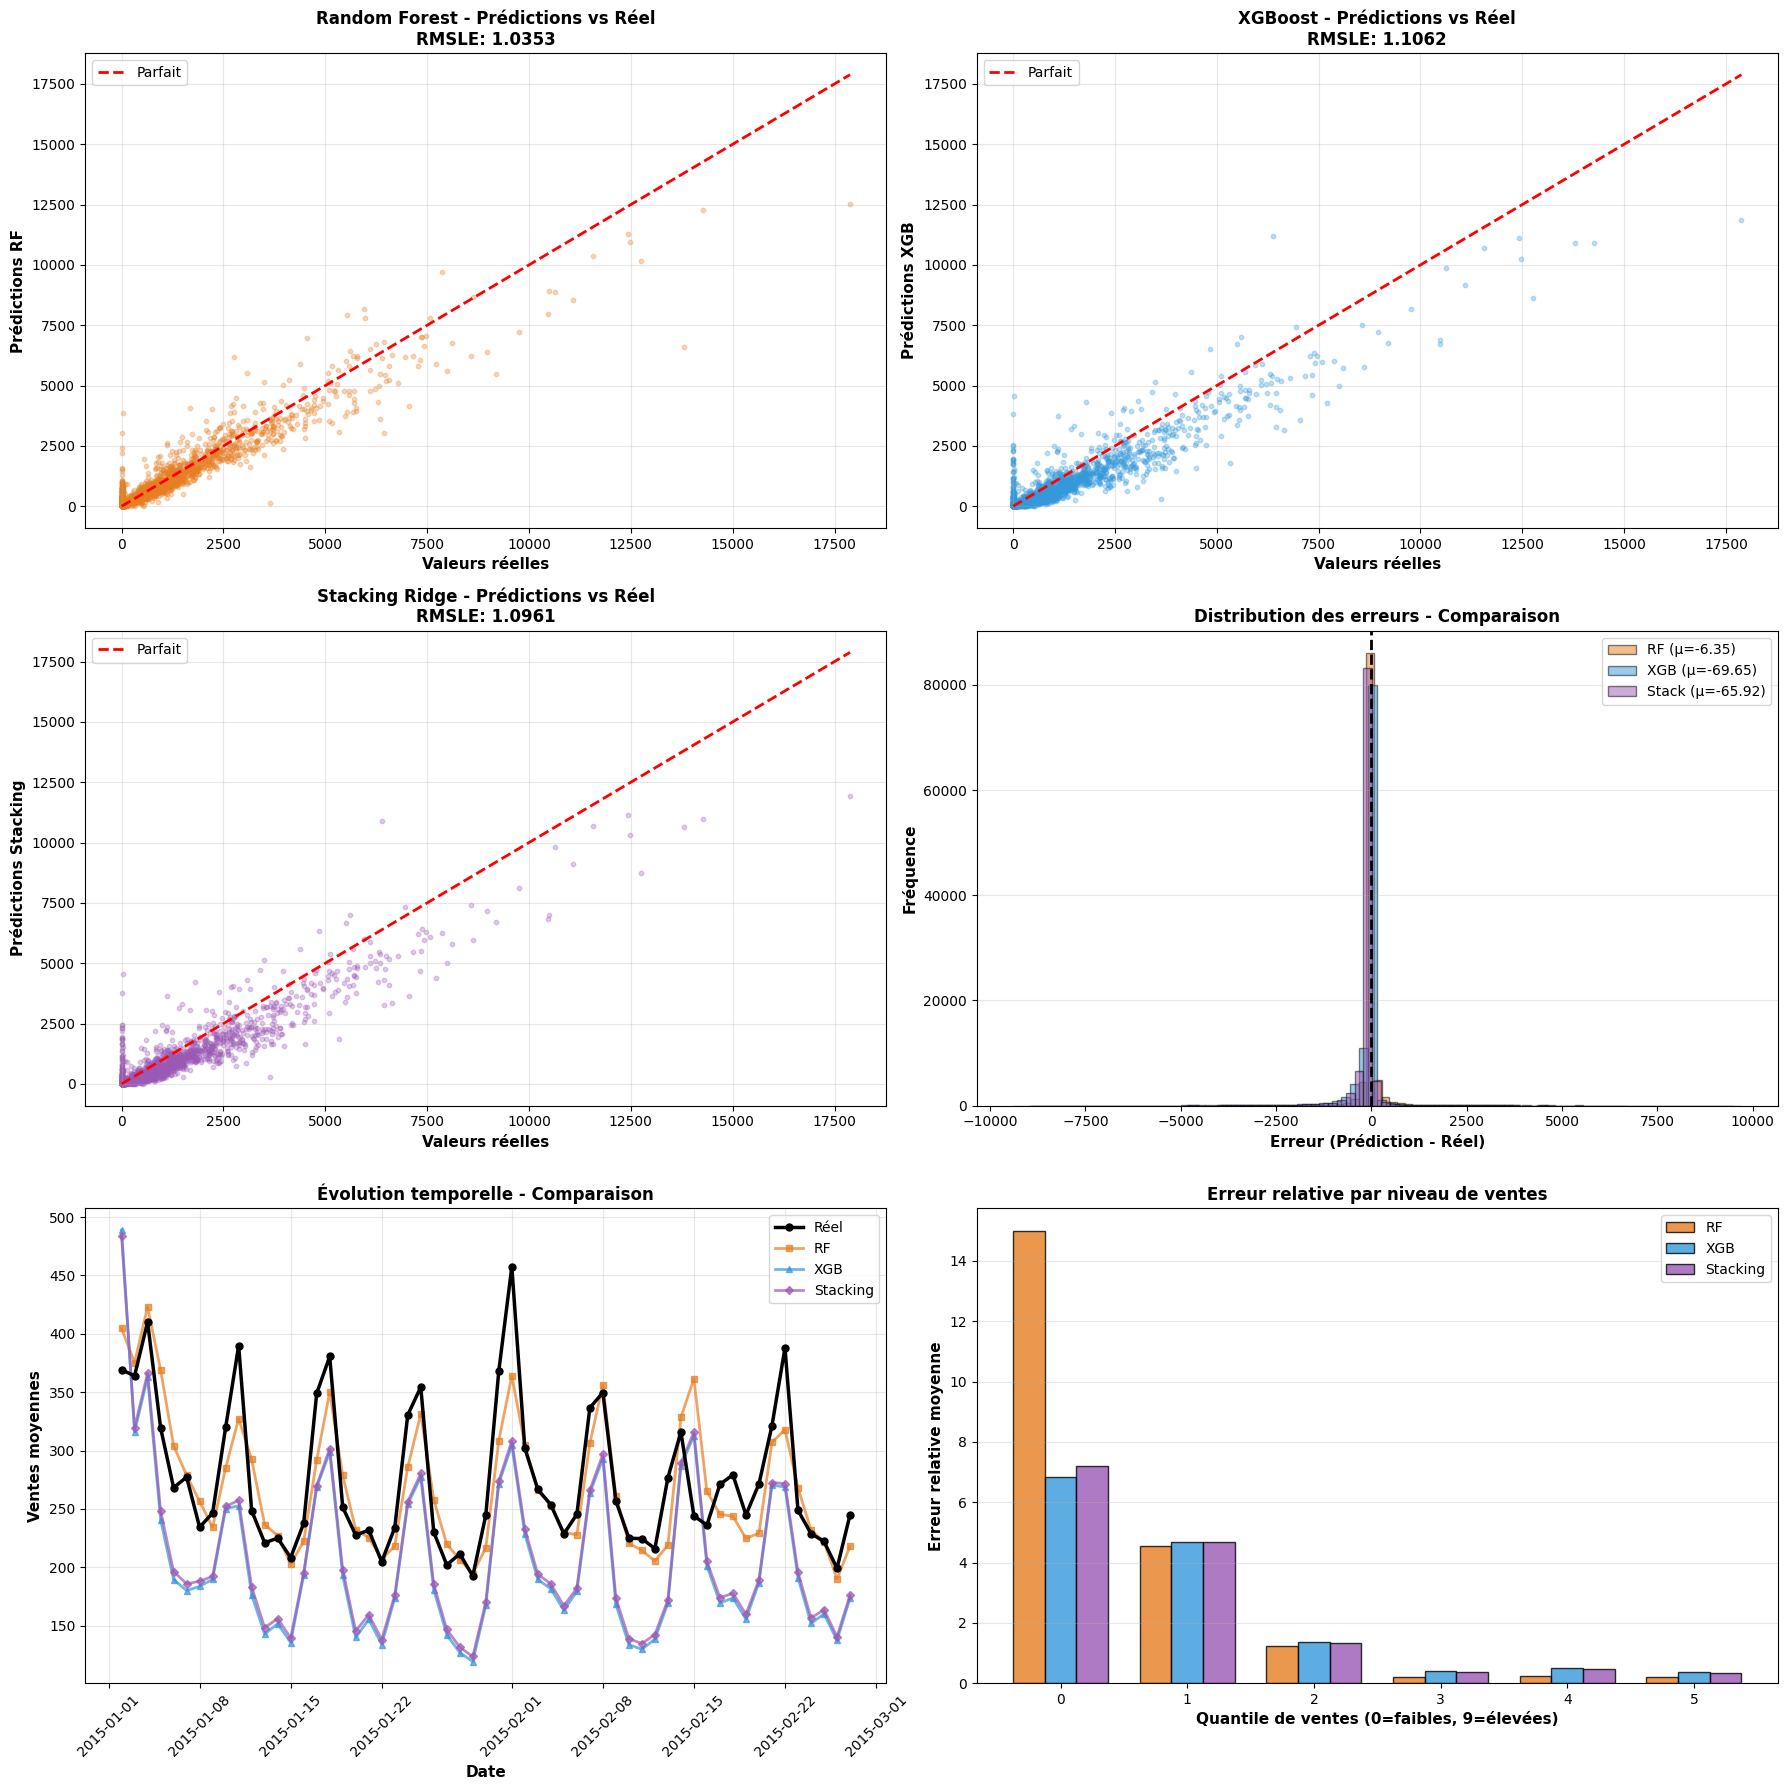


RÉCAPITULATIF DES PERFORMANCES - STACKING OOF
          Split RF_RMSLE XGB_RMSLE Stack_RMSLE Amélioration RF_Weight XGB_Weight
Split 1 (2 ans)   1.0353    1.1062      1.0961        0.06%     0.061      0.941
Split 2 (3 ans)   0.5528    0.9125      0.9731        0.01%    -0.008      1.010
Split 3 (Final)   0.4188    0.4463      0.4651        0.02%     0.036      0.966

────────────────────────────────────────────────────────────────────────────────────────────────────
MOYENNES:
  RF   : 0.6690
  XGB  : 0.8217
  Stack: 0.8448
  Amélioration moyenne: 0.03%


In [57]:
# ============================================================================
# GRAPHIQUES PRINCIPAUX - STACKING OOF (RF + XGB + Ridge)
# ============================================================================

fig, axes = plt.subplots(3, 2, figsize=(18, 18))

# Préparer les données
predictions_df_stacking = all_results_stacking_oof[0]['predictions'].copy()  # Ajuster l'index si besoin

# ============================================================================
# LIGNE 1 : COMPARAISON SCATTER PLOTS
# ============================================================================

sample_size = min(10000, len(predictions_df_stacking))
sample_idx = np.random.choice(len(predictions_df_stacking), sample_size, replace=False)
sample_df = predictions_df_stacking.iloc[sample_idx]

max_val = max(predictions_df_stacking['y_true'].max(), 
              predictions_df_stacking[['y_pred_rf', 'y_pred_xgb', 'y_pred']].max().max())

# 1. Scatter RF
ax1 = axes[0, 0]
ax1.scatter(sample_df['y_true'], sample_df['y_pred_rf'], alpha=0.3, s=10, color='#e67e22')
ax1.plot([0, max_val], [0, max_val], 'r--', linewidth=2, label='Parfait')
ax1.set_xlabel('Valeurs réelles', fontsize=11, fontweight='bold')
ax1.set_ylabel('Prédictions RF', fontsize=11, fontweight='bold')
ax1.set_title(f'Random Forest - Prédictions vs Réel\nRMSLE: {all_results_stacking_oof[0]["metrics_rf"]["rmsle"]:.4f}', 
              fontsize=12, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Scatter XGB
ax2 = axes[0, 1]
ax2.scatter(sample_df['y_true'], sample_df['y_pred_xgb'], alpha=0.3, s=10, color='#3498db')
ax2.plot([0, max_val], [0, max_val], 'r--', linewidth=2, label='Parfait')
ax2.set_xlabel('Valeurs réelles', fontsize=11, fontweight='bold')
ax2.set_ylabel('Prédictions XGB', fontsize=11, fontweight='bold')
ax2.set_title(f'XGBoost - Prédictions vs Réel\nRMSLE: {all_results_stacking_oof[0]["metrics_xgb"]["rmsle"]:.4f}', 
              fontsize=12, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

# ============================================================================
# LIGNE 2 : STACKING ET DISTRIBUTION DES ERREURS
# ============================================================================

# 3. Scatter Stacking
ax3 = axes[1, 0]
ax3.scatter(sample_df['y_true'], sample_df['y_pred'], alpha=0.3, s=10, color='#9b59b6')
ax3.plot([0, max_val], [0, max_val], 'r--', linewidth=2, label='Parfait')
ax3.set_xlabel('Valeurs réelles', fontsize=11, fontweight='bold')
ax3.set_ylabel('Prédictions Stacking', fontsize=11, fontweight='bold')
ax3.set_title(f'Stacking Ridge - Prédictions vs Réel\nRMSLE: {all_results_stacking_oof[0]["metrics"]["rmsle"]:.4f}', 
              fontsize=12, fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3)

# 4. Distribution des erreurs comparée
ax4 = axes[1, 1]
errors_rf = predictions_df_stacking['y_pred_rf'] - predictions_df_stacking['y_true']
errors_xgb = predictions_df_stacking['y_pred_xgb'] - predictions_df_stacking['y_true']
errors_stack = predictions_df_stacking['y_pred'] - predictions_df_stacking['y_true']

ax4.hist(errors_rf, bins=80, alpha=0.5, color='#e67e22', label=f'RF (μ={errors_rf.mean():.2f})', edgecolor='black')
ax4.hist(errors_xgb, bins=80, alpha=0.5, color='#3498db', label=f'XGB (μ={errors_xgb.mean():.2f})', edgecolor='black')
ax4.hist(errors_stack, bins=80, alpha=0.5, color='#9b59b6', label=f'Stack (μ={errors_stack.mean():.2f})', edgecolor='black')
ax4.axvline(x=0, color='black', linestyle='--', linewidth=2)
ax4.set_xlabel('Erreur (Prédiction - Réel)', fontsize=11, fontweight='bold')
ax4.set_ylabel('Fréquence', fontsize=11, fontweight='bold')
ax4.set_title('Distribution des erreurs - Comparaison', fontsize=12, fontweight='bold')
ax4.legend()
ax4.grid(True, alpha=0.3, axis='y')

# ============================================================================
# LIGNE 3 : ÉVOLUTION TEMPORELLE ET ERREURS PAR QUANTILE
# ============================================================================

# 5. Évolution temporelle (moyenne quotidienne)
ax5 = axes[2, 0]
daily_agg = predictions_df_stacking.groupby('date').agg({
    'y_true': 'mean',
    'y_pred_rf': 'mean',
    'y_pred_xgb': 'mean',
    'y_pred': 'mean'
}).reset_index()

ax5.plot(daily_agg['date'], daily_agg['y_true'], label='Réel', 
         linewidth=2.5, color='black', marker='o', markersize=5, zorder=5)
ax5.plot(daily_agg['date'], daily_agg['y_pred_rf'], label='RF', 
         linewidth=2, color='#e67e22', marker='s', markersize=4, alpha=0.7)
ax5.plot(daily_agg['date'], daily_agg['y_pred_xgb'], label='XGB', 
         linewidth=2, color='#3498db', marker='^', markersize=4, alpha=0.7)
ax5.plot(daily_agg['date'], daily_agg['y_pred'], label='Stacking', 
         linewidth=2, color='#9b59b6', marker='D', markersize=4, alpha=0.7)

ax5.set_xlabel('Date', fontsize=11, fontweight='bold')
ax5.set_ylabel('Ventes moyennes', fontsize=11, fontweight='bold')
ax5.set_title('Évolution temporelle - Comparaison', fontsize=12, fontweight='bold')
ax5.legend(loc='best')
ax5.grid(True, alpha=0.3)
ax5.tick_params(axis='x', rotation=45)

# 6. Erreurs relatives par quantile de ventes
ax6 = axes[2, 1]
predictions_df_copy = predictions_df_stacking.copy()

# Calculer erreurs relatives
for col in ['y_pred_rf', 'y_pred_xgb', 'y_pred']:
    predictions_df_copy[f'rel_error_{col}'] = (
        np.abs(predictions_df_copy[col] - predictions_df_copy['y_true']) / 
        (predictions_df_copy['y_true'] + 1)
    )

# Créer des quantiles de ventes
predictions_df_copy['sales_quantile'] = pd.qcut(
    predictions_df_copy['y_true'], 
    q=10, 
    labels=False, 
    duplicates='drop'
)

quantile_errors_rf = predictions_df_copy.groupby('sales_quantile')['rel_error_y_pred_rf'].mean()
quantile_errors_xgb = predictions_df_copy.groupby('sales_quantile')['rel_error_y_pred_xgb'].mean()
quantile_errors_stack = predictions_df_copy.groupby('sales_quantile')['rel_error_y_pred'].mean()

x = np.arange(len(quantile_errors_rf))
width = 0.25

ax6.bar(x - width, quantile_errors_rf.values, width, label='RF', color='#e67e22', alpha=0.8, edgecolor='black')
ax6.bar(x, quantile_errors_xgb.values, width, label='XGB', color='#3498db', alpha=0.8, edgecolor='black')
ax6.bar(x + width, quantile_errors_stack.values, width, label='Stacking', color='#9b59b6', alpha=0.8, edgecolor='black')

ax6.set_xlabel('Quantile de ventes (0=faibles, 9=élevées)', fontsize=11, fontweight='bold')
ax6.set_ylabel('Erreur relative moyenne', fontsize=11, fontweight='bold')
ax6.set_title('Erreur relative par niveau de ventes', fontsize=12, fontweight='bold')
ax6.set_xticks(x)
ax6.set_xticklabels(quantile_errors_rf.index)
ax6.legend()
ax6.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# ============================================================================
# GRAPHIQUE BONUS : POIDS RIDGE ET OOF SCORES
# ============================================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Poids Ridge par split
ax1 = axes[0]
splits_names = [res['split_name'].replace(' (Stacking OOF)', '') for res in all_results_stacking_oof]
rf_weights = [res['ridge_coefs']['rf'] for res in all_results_stacking_oof]
xgb_weights = [res['ridge_coefs']['xgb'] for res in all_results_stacking_oof]

x = np.arange(len(splits_names))
width = 0.35

bars1 = ax1.bar(x - width/2, rf_weights, width, label='Poids RF', color='#e67e22', alpha=0.8, edgecolor='black')
bars2 = ax1.bar(x + width/2, xgb_weights, width, label='Poids XGB', color='#3498db', alpha=0.8, edgecolor='black')

# Ajouter les valeurs sur les barres
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}',
                ha='center', va='bottom', fontsize=9, fontweight='bold')

ax1.set_xlabel('Split', fontsize=12, fontweight='bold')
ax1.set_ylabel('Poids Ridge', fontsize=12, fontweight='bold')
ax1.set_title('Coefficients Ridge par split', fontsize=13, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(splits_names, rotation=0)
ax1.legend()
ax1.grid(True, alpha=0.3, axis='y')
ax1.axhline(y=0, color='black', linestyle='-', linewidth=1)

# ============================================================================
# TABLEAU RÉCAPITULATIF
# ============================================================================

print("\n" + "="*100)
print("RÉCAPITULATIF DES PERFORMANCES - STACKING OOF")
print("="*100)

summary_data = []
for res in all_results_stacking_oof:
    split_name = res['split_name'].replace(' (Stacking OOF)', '')
    
    summary_data.append({
        'Split': split_name,
        'RF_RMSLE': f"{res['metrics_rf']['rmsle']:.4f}",
        'XGB_RMSLE': f"{res['metrics_xgb']['rmsle']:.4f}",
        'Stack_RMSLE': f"{res['metrics']['rmsle']:.4f}",
        'Amélioration': f"{res['oof_scores']['improvement']:.2f}%",
        'RF_Weight': f"{res['ridge_coefs']['rf']:.3f}",
        'XGB_Weight': f"{res['ridge_coefs']['xgb']:.3f}"
    })

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))

# Moyennes
print(f"\n{'─'*100}")
print(f"MOYENNES:")
print(f"  RF   : {np.mean([float(d['RF_RMSLE']) for d in summary_data]):.4f}")
print(f"  XGB  : {np.mean([float(d['XGB_RMSLE']) for d in summary_data]):.4f}")
print(f"  Stack: {np.mean([float(d['Stack_RMSLE']) for d in summary_data]):.4f}")
print(f"  Amélioration moyenne: {np.mean([float(d['Amélioration'].rstrip('%')) for d in summary_data]):.2f}%")

Stacking pas ouf, RF et XGB trop corrélés, ils font les mêmes erreurs 